# Laboratorium 4 zad. 3 - sprawozdanie
Autor: Szymon Januszek

## Sudoku
Napisz program poszukujący rozwiązania łamigłówki Sudoku za pomocą symulowanego
wyżarzania. Plansza 9 × 9 ma zostać wczytana z pliku tekstowego, w którym pola puste
zaznaczone są znakiem x. Jako funkcję kosztu przyjmij sumę powtórzeń cyfr występujących w wierszach bloku 9 × 9, kolumnach bloku 9 × 9 oraz blokach 3 × 3. Zaproponuj
metodę generacji stanu sąsiedniego. Przedstaw zależność liczby iteracji algorytmu od
liczby pustych miejsc na planszy. Czy Twój program jest w stanie znaleźć poprawne
rozwiązanie dla każdej z testowanych konfiguracji wejściowych?

### Import wymaganych bibliotek


In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import os

import subprocess

from IPython.display import Image, display, HTML

## Implementacja algorytmu wyżarzania do rozwiązywania plansz sudoku
Podobnie jak w poprzednich zadaniach algorytm został napisany w języku C. Program jest dostępny w pliku `SUDOKU.c`, został załączony do niego Makefile (wymagany jest kompilator gcc) oraz skrypt Python do uruchomienia.

Na początku dokonamy wypełnienia pustych miejsc na planszy losowymi cyframi z zakresu od 1 do 9.

Jako funkcję sąsiedztwa będziemy wybierać losową komórkę na planszy i zamieniać znajdującą się w niej cyfrę na losową inną.

Funkcję energii stanowi liczba powtórzeń danej cyfry w w tej samej kolumnie, rzędzie i w bloku 3x3.

Jako funkcje prawdopodbieństwa używamy $P(\Delta E, T) = e^{-\frac{\Delta E}{T}}$

Jako funkcje zmiany temperautury wykorzystujemy:
- #### Exponential cooling
  $T(i) = T_0 \cdot \alpha^i$

Poniższy kod minimalizuje energię zgodnie z algorytmem symulowanego wyżarzania i zapisuje log energii, początkową liczbę miejsc pustych, finalną energię oraz ostateczną wersję planszy.

```c
#include <math.h>
#include <stdio.h>
#include <stdlib.h>
#define N 9

struct Coords{
	int x;
	int y;
};

unsigned char* read_sudoku(char* filename) {
    FILE* input = fopen(filename, "r");

    unsigned char* data = (unsigned char *) malloc(N * N);
    int count = 0;

    while (count < N * N) {
        int c = fgetc(input);
        if (c == EOF) break;

        if (c == 'x' || (c >= '0' && c <= '9')) {
            data[count++] = (unsigned char)c;
        }
    }

    fclose(input);
    return data;
}

double get_local_energy(unsigned char* board, int x, int y) {
	char current = board[N * y + x];
	double energy = 0;

	if(current == 'x') {
		return energy;
	}

	for(int i = 0; i < N; i++) {
		if(x != i && board[N * y + i] == current) {
			energy += 1;
		}

		if (y != i && board[N * i + x] == current) {
			energy += 1;
		}
	}

	int start_x = (x / 3) * 3;
	int start_y = (y / 3) * 3;

	for(int i = start_y; i < start_y + 3; i++) {
		for(int j = start_x; j < start_x + 3; j++) {
			if(i != y && j != x && board[N * i + j] == current) {
				energy += 1;
			}
		}
	}

	return energy;
}

double get_full_energy(unsigned char* board) {
	double energy = 0;

	for(int y = 0; y < N; y++) {
		for(int x = 0; x < N; x++) {
			energy += get_local_energy(board, x, y);
		}
	}

	return energy;
}

int count_empty_spaces(unsigned char* board) {
	int count = 0;

	for(int y = 0; y < N; y++) {
		for(int x = 0; x < N; x++) {
			if(board[N * y + x] == 'x') {
				count += 1;
			}
		}
	}

	return count;
}

struct Coords* get_empty_spaces(unsigned char* board, int empty_count) {
	struct Coords* data = malloc(empty_count * sizeof(struct Coords));

	int id = 0;
	for(int y = 0; y < N; y++) {
		for(int x = 0; x < N; x++) {
			if(board[N * y + x] == 'x') {
				struct Coords point = {x,y};
				data[id] = point;
				id++;
			}
		}
	}

	return data;
}

void prefill_empty(unsigned char* board, struct Coords* empty_spaces, int empty_count) {
	for(int i = 0; i < empty_count; i++) {
		int x = empty_spaces[i].x;
		int y = empty_spaces[i].y;

		board[N * y + x] = (rand() % 9) + 1 + '0';
	}
}

void print_board(unsigned char* board) {
	for(int y = 0; y < N; y++) {
		for(int x = 0; x < N; x++) {
			printf("%c",board[N * y + x]);
		}
		printf("\n");
	}
}

void simulated_annealing(unsigned char* board, double temp, double step_lower, char* out_dir) {
	int empty_count = count_empty_spaces(board);
	struct Coords* empty_spaces = get_empty_spaces(board, empty_count);

	prefill_empty(board, empty_spaces, empty_count);

	double current_energy = get_full_energy(board);
	int count_iter = 0;

	char energy_path[512];

	sprintf(energy_path, "%s/energy_log.csv", out_dir);
	FILE* f_energy = fopen(energy_path, "w");
	fprintf(f_energy, "iteration,energy\n");

	while(temp > 1e-2 && current_energy != 0 && count_iter < 6000000) {
		if(count_iter % 1000 == 0) {
			fprintf(f_energy, "%d,%f\n", count_iter, current_energy);
		}

		int e_id = rand() % empty_count;
		int n_x = empty_spaces[e_id].x;
		int n_y = empty_spaces[e_id].y;

		char new_val;
		do {
			new_val = (rand() % 9) + 1 + '0';
		}while (new_val == board[N * n_y + n_x]);

		int n_id = N * n_y + n_x;

		double old_energy = get_local_energy(board, n_x, n_y);
		
		char old_val = board[n_id];
		board[n_id] = new_val;

		double new_energy = get_local_energy(board, n_x, n_y);

		double delta = new_energy - old_energy;

		if(delta < 0 || ((double) rand() / RAND_MAX) < exp((-delta * 2) / temp)) {
			current_energy += (delta * 2);
		} else {
			board[n_id] = old_val;
		}

		temp *= step_lower;
		count_iter++;
	}
	fprintf(f_energy, "%d,%f\n", count_iter, current_energy);
	fclose(f_energy);
	free(empty_spaces);
}

int main(int argc, char* argv[]) {
    	char* input_file = argv[1];
	char* out_dir = argv[2];
	double temp = atof(argv[3]);
    	double temp_lower = atof(argv[4]);

	unsigned char* board = read_sudoku(input_file);
	int initial_empty = count_empty_spaces(board);

	simulated_annealing(board, temp, temp_lower, out_dir);

	char board_path[256];
    	sprintf(board_path, "%s/final_board.txt", out_dir);
    	FILE* f_board = fopen(board_path, "w");
    	for(int y = 0; y < N; y++) {
		for(int x = 0; x < N; x++) {
	    		fprintf(f_board, "%c", board[N * y + x]);
		}
		fprintf(f_board, "\n");
    	}
    	fclose(f_board);

	char stats_path[256];
	sprintf(stats_path, "%s/stats.txt", out_dir);
	FILE* f_stats = fopen(stats_path, "w");
	fprintf(f_stats, "empty_spaces: %d\n", initial_empty);
	fprintf(f_stats, "final_energy: %f\n", get_full_energy(board));
	fclose(f_stats);

	free(board);
}

```

## Dane wejściowe
Program będziemy testować na 16 planszach sudoku o różnej trudności pochodzących z https://people.sc.fsu.edu/~jburkardt/data/sudoku/sudoku.html

## Program runner

### Stałe

In [2]:
TEMP = 50
TEMP_LOWER = 0.999999

### Runner

In [3]:
def run():
    for input_file in os.listdir("boards"):
        input_path = f"boards/{input_file}"

        folder_name = f"{input_file.strip(".txt")}"
        out_path = f"output/{folder_name}"
        os.makedirs(out_path, exist_ok=True)

        command = [
                "./SUDOKU",
                input_path,
                out_path,
                str(TEMP),
                str(TEMP_LOWER)
                ]

        subprocess.run(command)

## Wizualizacje
Program wygeneruje obrazy podsumowujące dla każdego testu oraz porównanie liczby iteracji do liczby pustych pól.

In [10]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import os

def read_board(file_path):
    with open(file_path, 'r') as f:
        data = f.read().replace('\n', '').replace(' ', '')
        return np.array(list(data)).reshape(9, 9)

def get_empty_count(file_path):
    if not os.path.exists(file_path): return 0
    with open(file_path, 'r') as f:
        return f.read().count('x')

def draw_sudoku(ax, board, title):
    ax.set_aspect('equal')
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    
    conflicts = np.zeros((9, 9), dtype=bool)
    for y in range(9):
        for x in range(9):
            val = board[y, x]
            if val == 'x' or val == '0':
                continue
            
            row_vals = list(board[y, :])
            col_vals = list(board[:, x])
            if row_vals.count(val) > 1 or col_vals.count(val) > 1:
                conflicts[y, x] = True
                continue
            
            bx, by = (x // 3) * 3, (y // 3) * 3
            block = board[by:by+3, bx:bx+3].flatten()
            if list(block).count(val) > 1:
                conflicts[y, x] = True

    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.5
        ax.axhline(i, color='black', lw=lw)
        ax.axvline(i, color='black', lw=lw)

    for y in range(9):
        for x in range(9):
            val = board[y, x]
            
            if conflicts[y, x]:
                rect = plt.Rectangle((x, 8-y), 1, 1, color='#ffcccc', zorder=0)
                ax.add_patch(rect)
            elif val == 'x':
                rect = plt.Rectangle((x, 8-y), 1, 1, color='whitesmoke', zorder=0)
                ax.add_patch(rect)

            if val != 'x' and val != '0':
                ax.text(x + 0.5, 8 - y + 0.5, str(val), 
                        va='center', ha='center', fontsize=14, 
                        fontweight='bold', fontfamily='serif',
                        color='red' if conflicts[y, x] else 'black')

    ax.set_title(title, pad=15, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

def create_sudoku_report(input_file, out_dir, save_path):
    try:
        initial_board = read_board(input_file)
        final_board = read_board(f"{out_dir}/final_board.txt")
        energy_df = pd.read_csv(f"{out_dir}/energy_log.csv")
        
        stats = {}
        if os.path.exists(f"{out_dir}/stats.txt"):
            with open(f"{out_dir}/stats.txt", 'r') as f:
                for line in f:
                    if ': ' in line:
                        k, v = line.strip().split(': ')
                        stats[k] = v
        
        final_energy = float(stats.get('final_energy', 0))
        
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None

    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])

    puzzle_name = out_dir.split("/")[1].split("_")
    
    header_text = f" PUZZLE: {puzzle_name[0].upper()} {puzzle_name[1]} | INITIAL EMPTY: {stats.get('empty_spaces', 'N/A')} | FINAL ENERGY: {final_energy}"
    plt.suptitle(header_text, fontsize=16, fontweight='bold', y=0.98)

    ax_init = fig.add_subplot(gs[0, 0])
    draw_sudoku(ax_init, initial_board, "Initial State")

    ax_solved = fig.add_subplot(gs[0, 1])
    draw_sudoku(ax_solved, final_board, "Final State")

    ax_energy = fig.add_subplot(gs[1, :])
    ax_energy.plot(energy_df['iteration'], energy_df['energy'], color='crimson', lw=1.5)
    ax_energy.set_title("Energy Graph", fontsize=12, fontweight='bold')
    ax_energy.set_xlabel("Iteration")
    ax_energy.set_ylabel("Total Energy")
    ax_energy.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path, dpi=150)
    plt.close()
    
    return energy_df['iteration'].iloc[-1], final_energy

def visualize():
    output_base = "output"
    input_base = "boards"
    visuals_base = "visuals"
    
    os.makedirs(visuals_base, exist_ok=True)
    
    global_stats = []

    for i in range(1, 17):
        p_id = f"{i:02d}"
        folder_name = f"puzzle_{p_id}"
        
        input_file = os.path.join(input_base, f"{folder_name}.txt")
        out_dir = os.path.join(output_base, folder_name)
        save_path = os.path.join(visuals_base, f"summary_{folder_name}.png")

        if os.path.isdir(out_dir):
            total_iters, final_energy = create_sudoku_report(input_file, out_dir, save_path)
            
            if total_iters is not None:
                empty_cells = get_empty_count(input_file)
                global_stats.append({
                    "id": p_id,
                    "empty": empty_cells,
                    "iters": total_iters,
                    "energy": final_energy
                })

    if global_stats:
        df = pd.DataFrame(global_stats).sort_values(by='empty')
        
        solved = df[df['energy'] == 0]
        failed = df[df['energy'] > 0]
        
        plt.figure(figsize=(12, 7))
        plt.yscale('log')
        
        if not solved.empty:
            plt.scatter(solved['empty'], solved['iters'], color='tab:blue', s=120, 
                        edgecolors='black', zorder=3)
            
            if len(solved) > 1:
                z = np.polyfit(solved['empty'], np.log10(solved['iters']), 1)
                p = np.poly1d(z)
                x_range = np.linspace(df['empty'].min(), df['empty'].max(), 100)
                plt.plot(x_range, 10**p(x_range), "r--", lw=2, alpha=0.7)

        if not failed.empty:
            plt.scatter(failed['empty'], failed['iters'], color='red', marker='x', 
                        s=150, lw=3, zorder=3)

        for idx, row in df.iterrows():
            plt.annotate(row['id'], (row['empty'], row['iters']), xytext=(0, 8), 
                         textcoords='offset points', ha='center', fontweight='bold')

        plt.title("Iterations vs. Difficulty", fontsize=15, fontweight='bold')
        plt.xlabel("Initial Empty Cells", fontsize=12)
        plt.ylabel("Iterations", fontsize=12)
        plt.grid(True, which="both", linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(visuals_base, "performance.png"), dpi=200)

## Uruchomienie programu

In [6]:
raise Exception("Uruchamia program, ale wykonuje się bardzo szybko")
run()
visualize()

Exception: Uruchamia program, ale wykonuje się bardzo szybko

## Wyniki

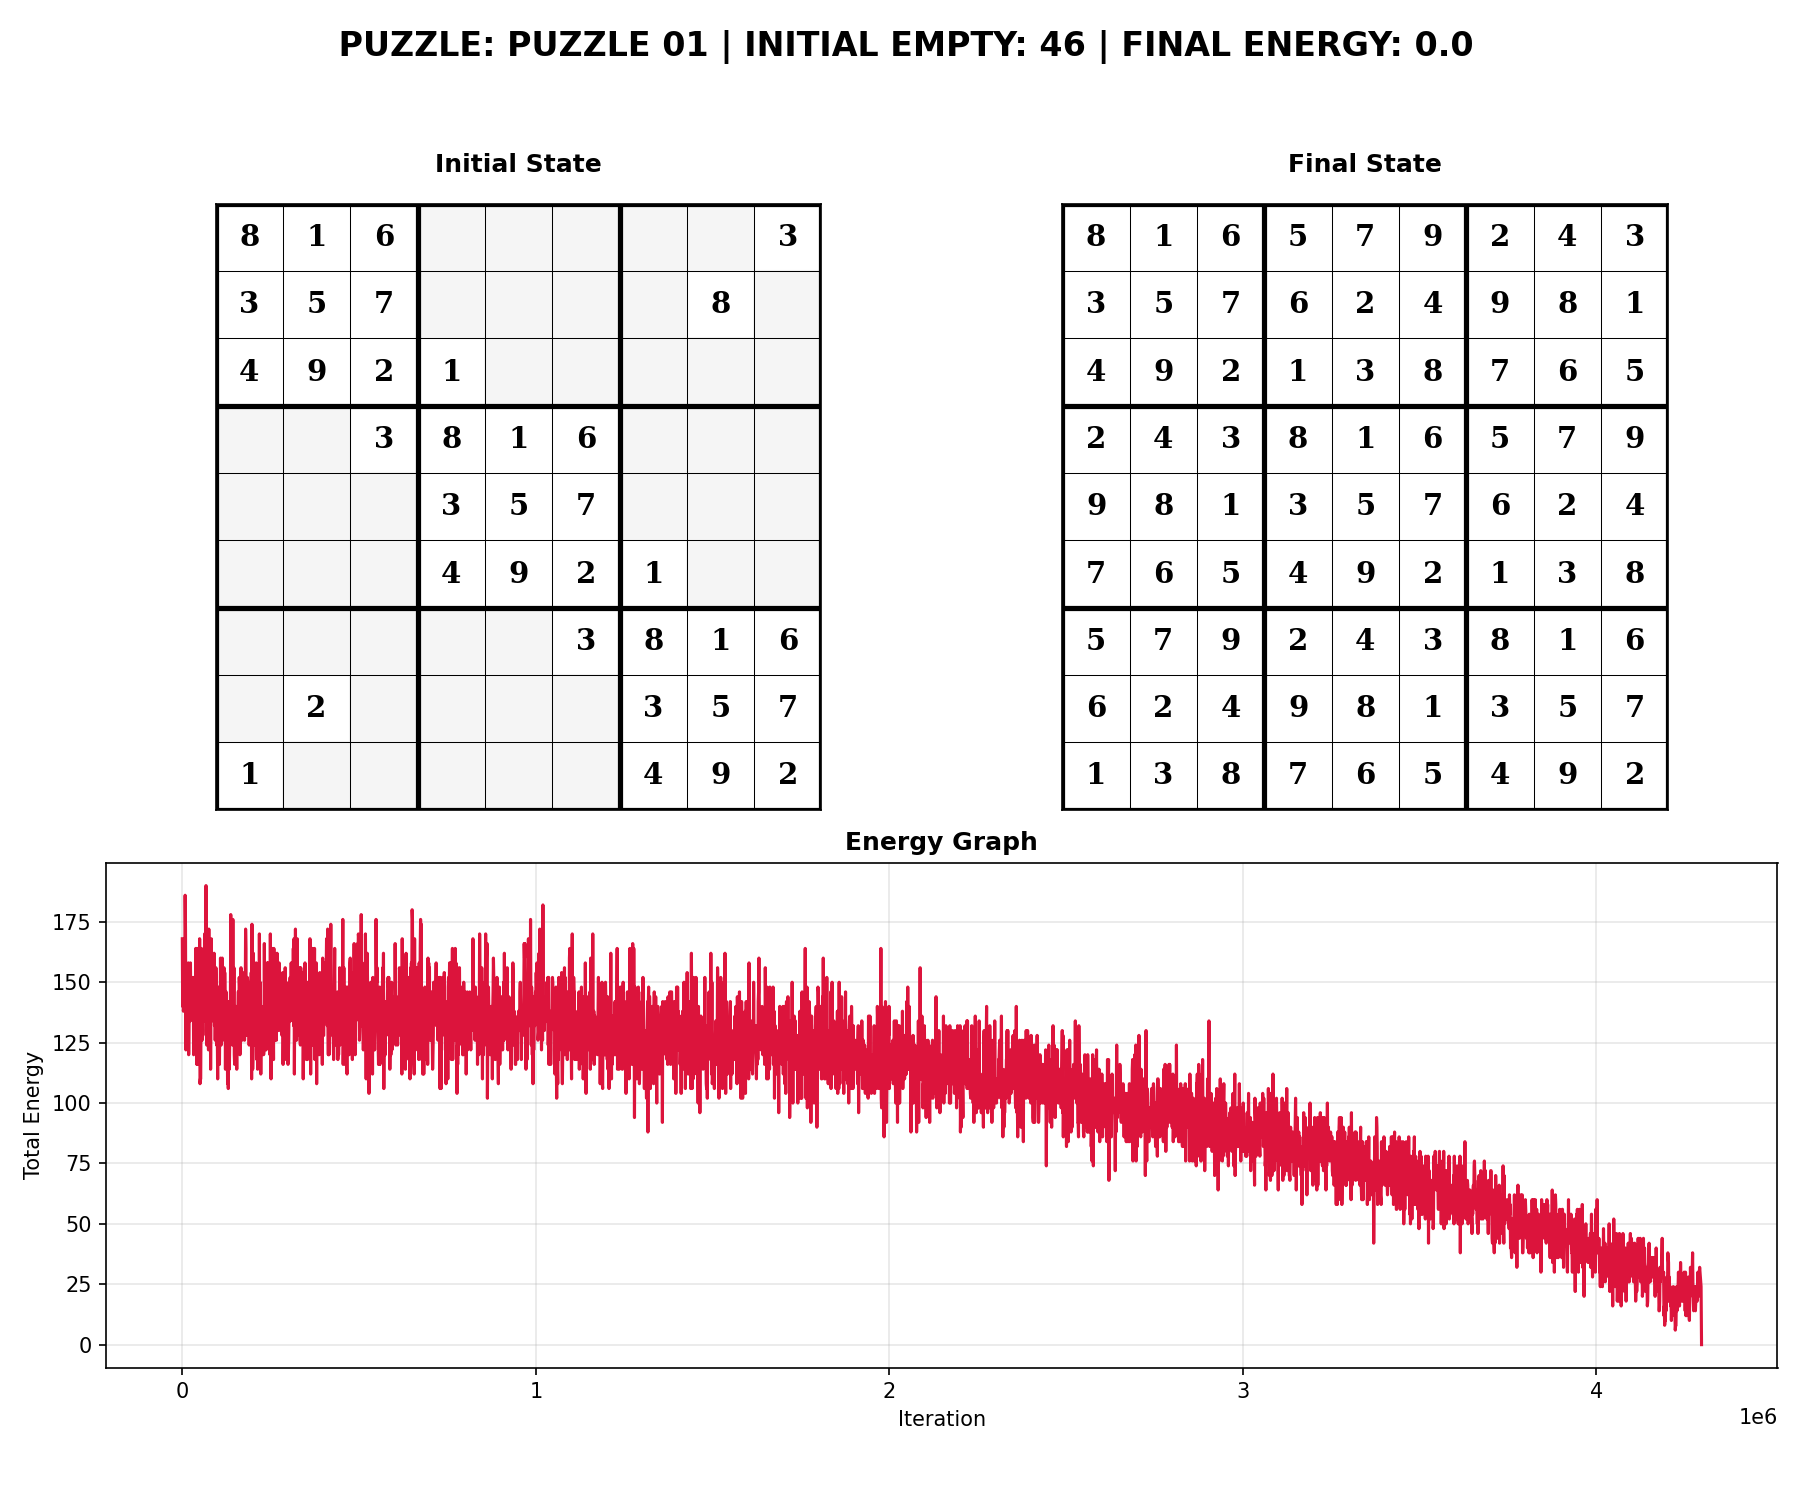

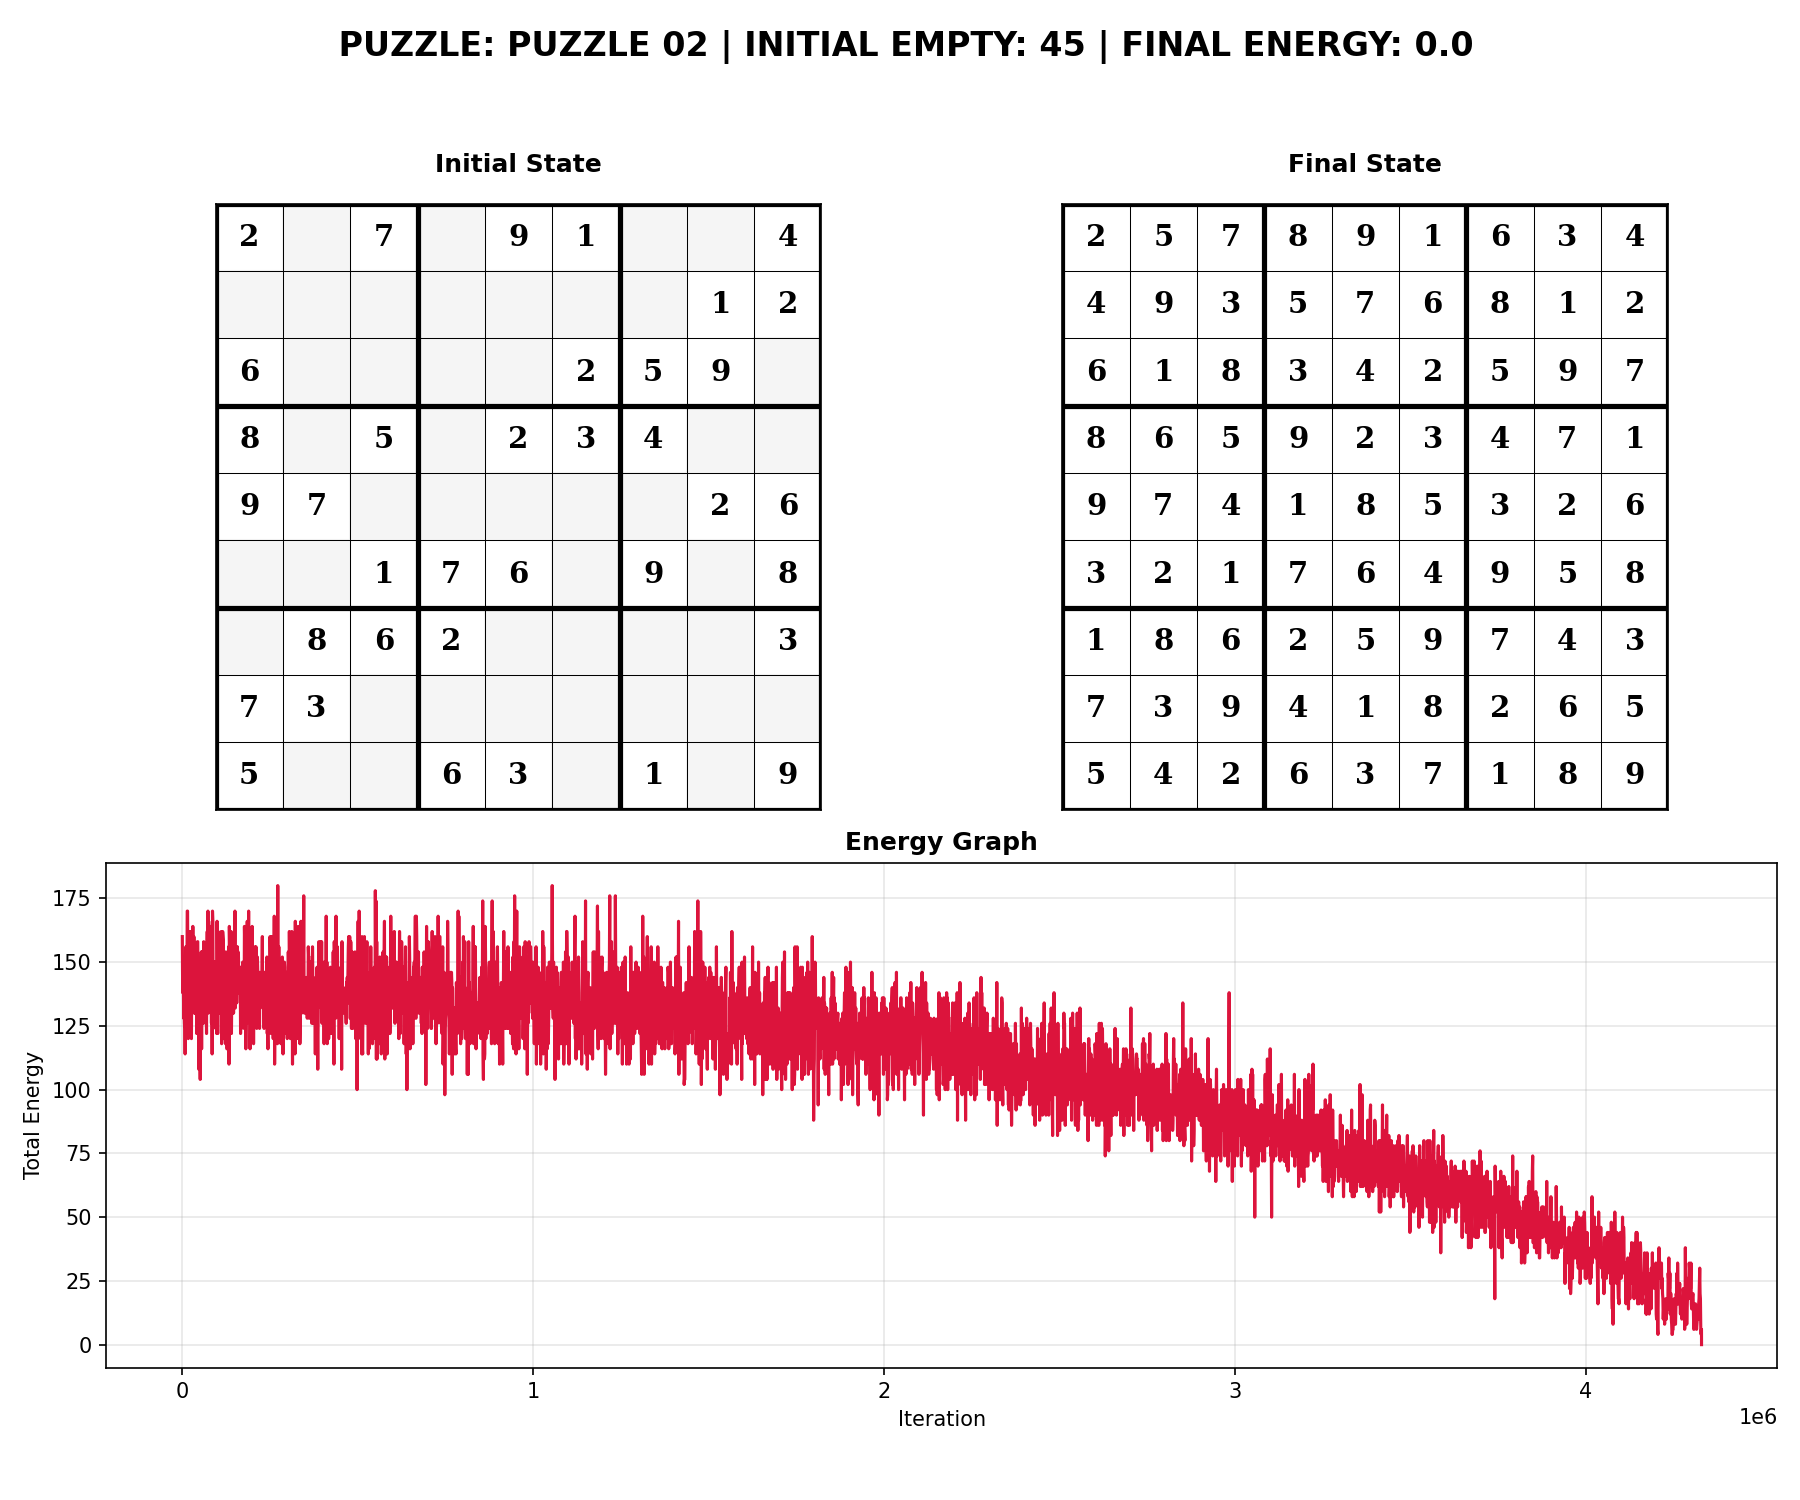

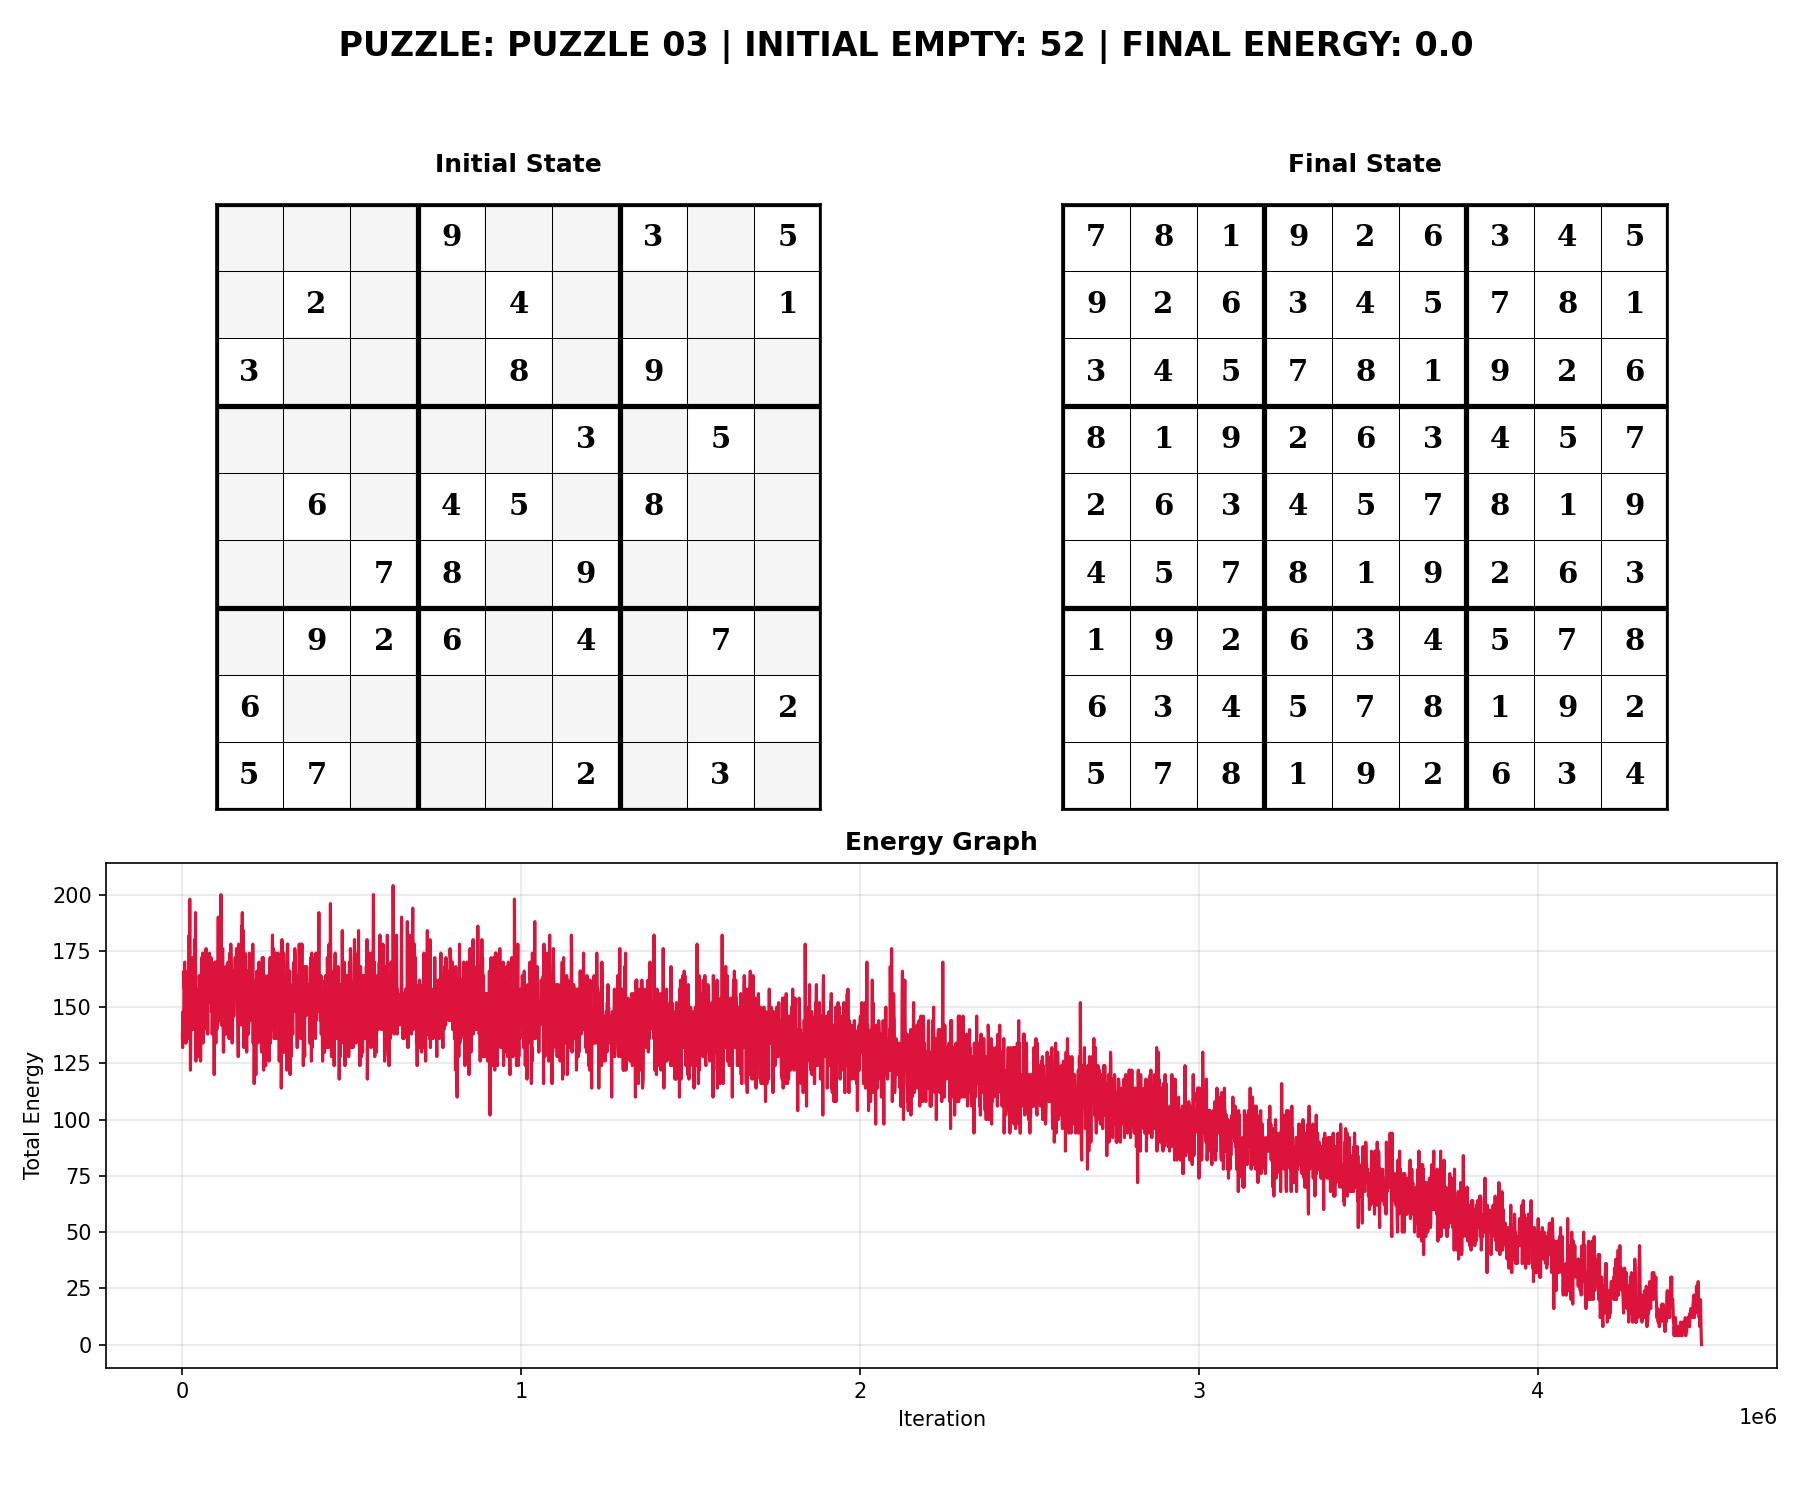

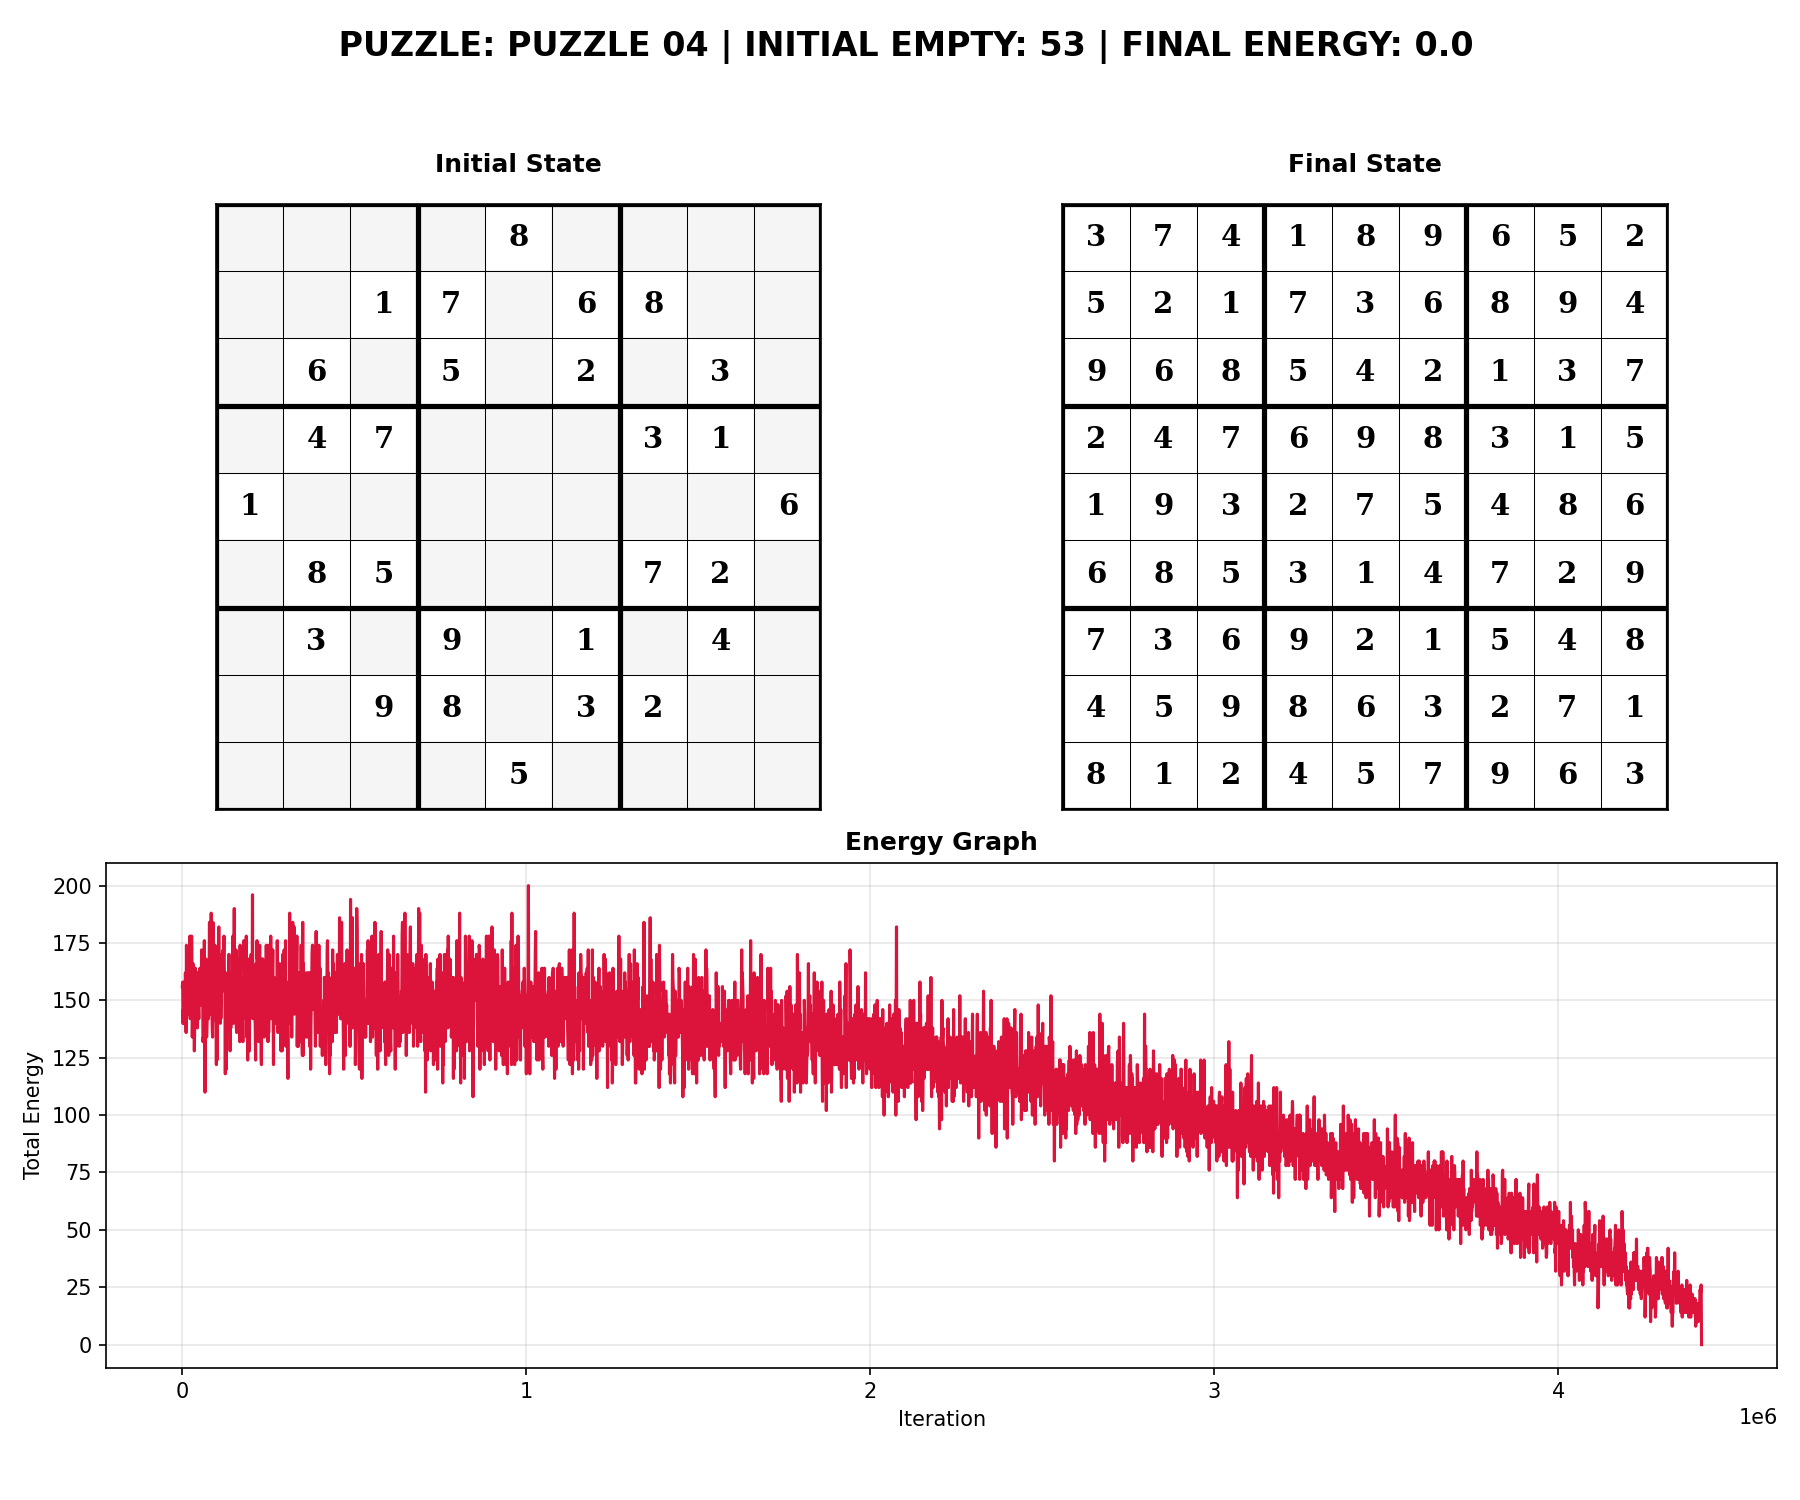

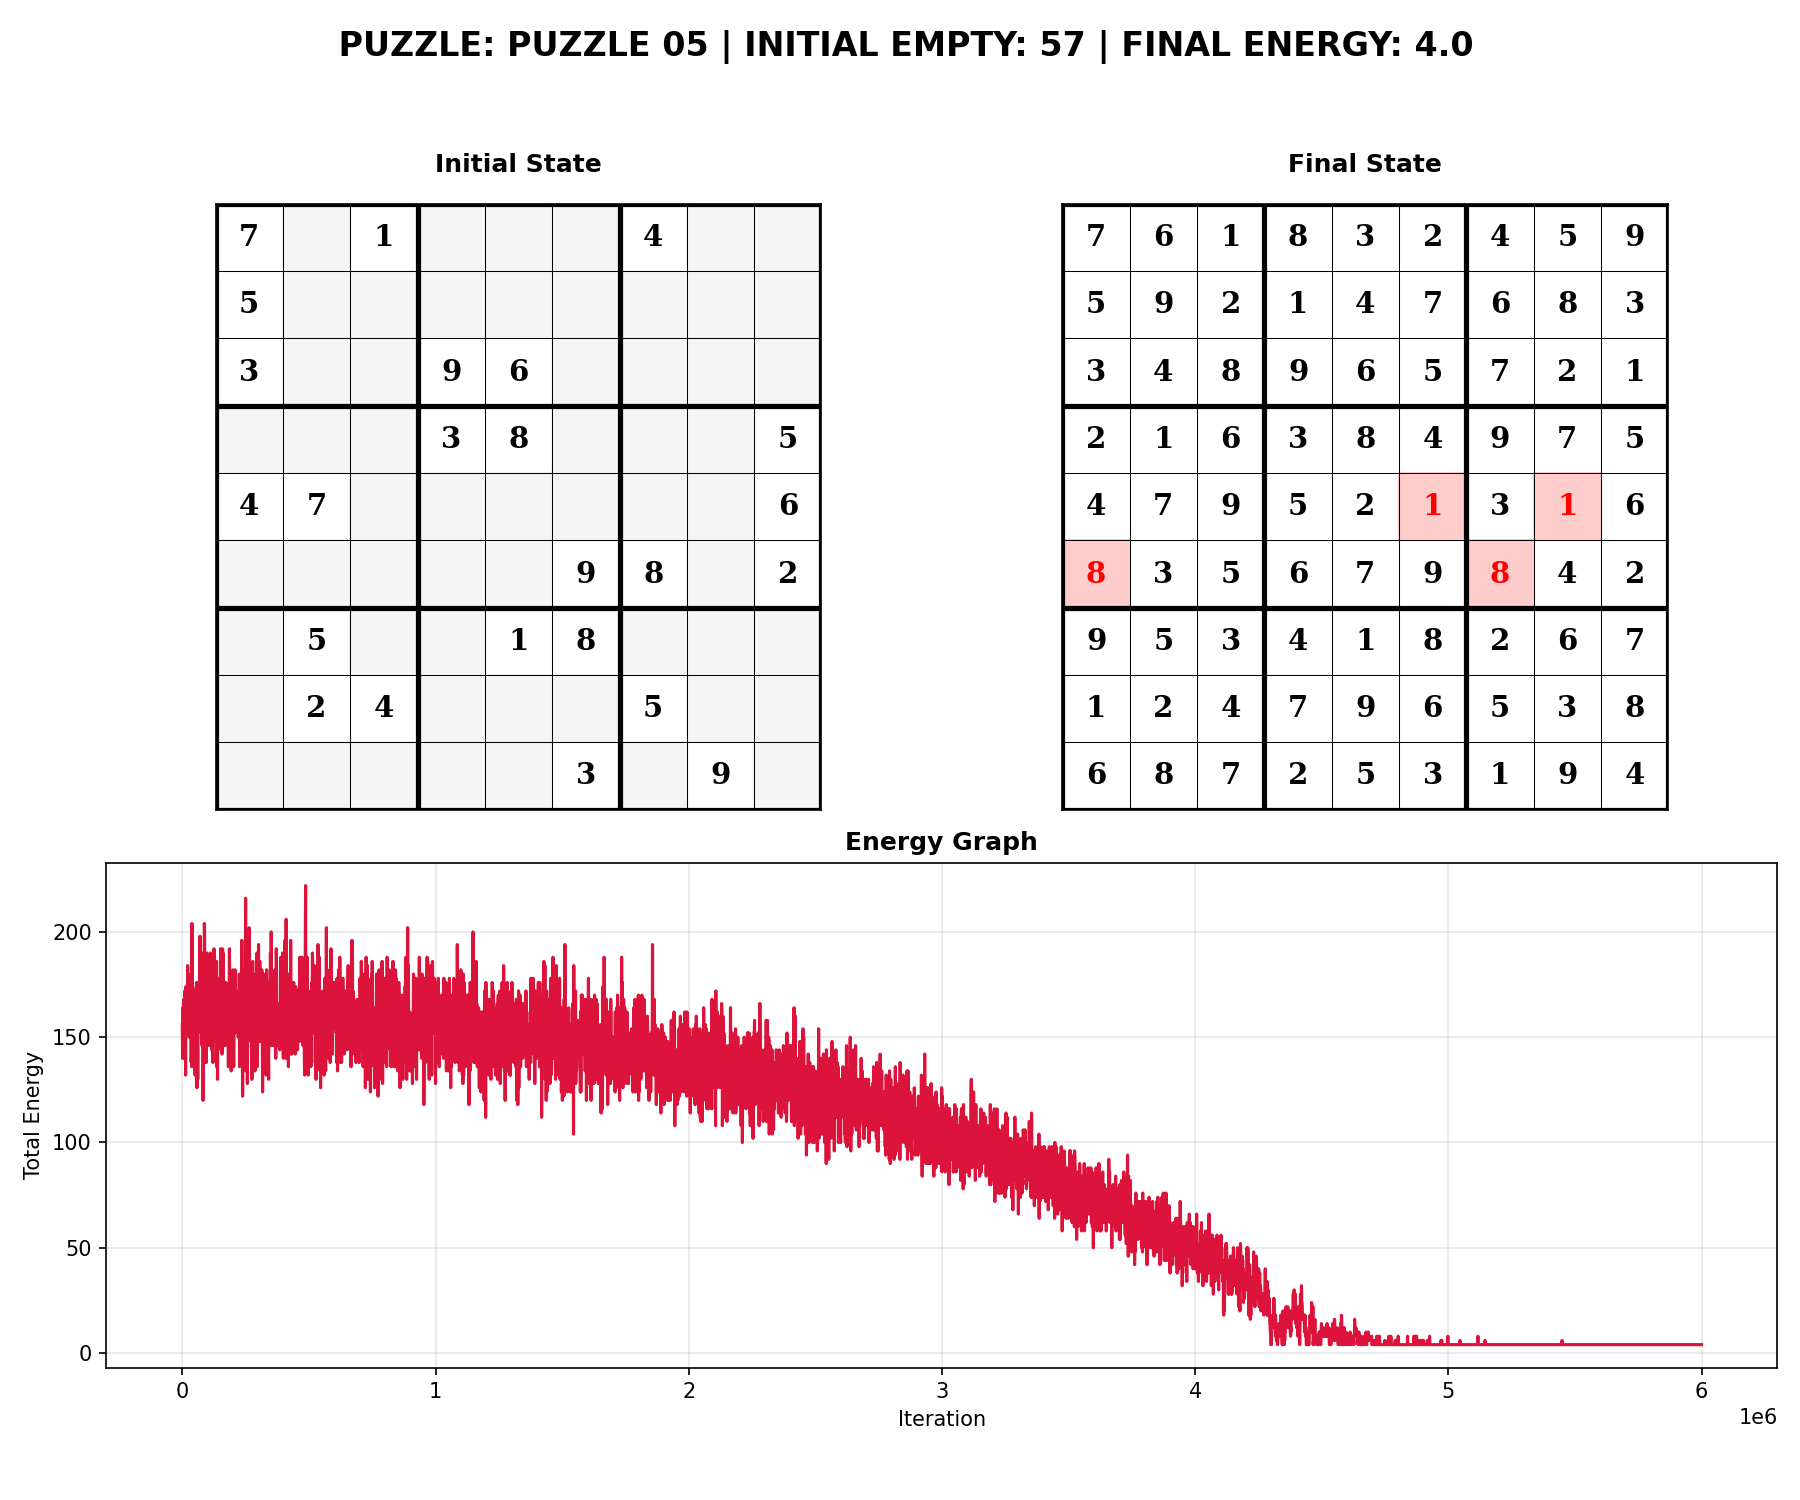

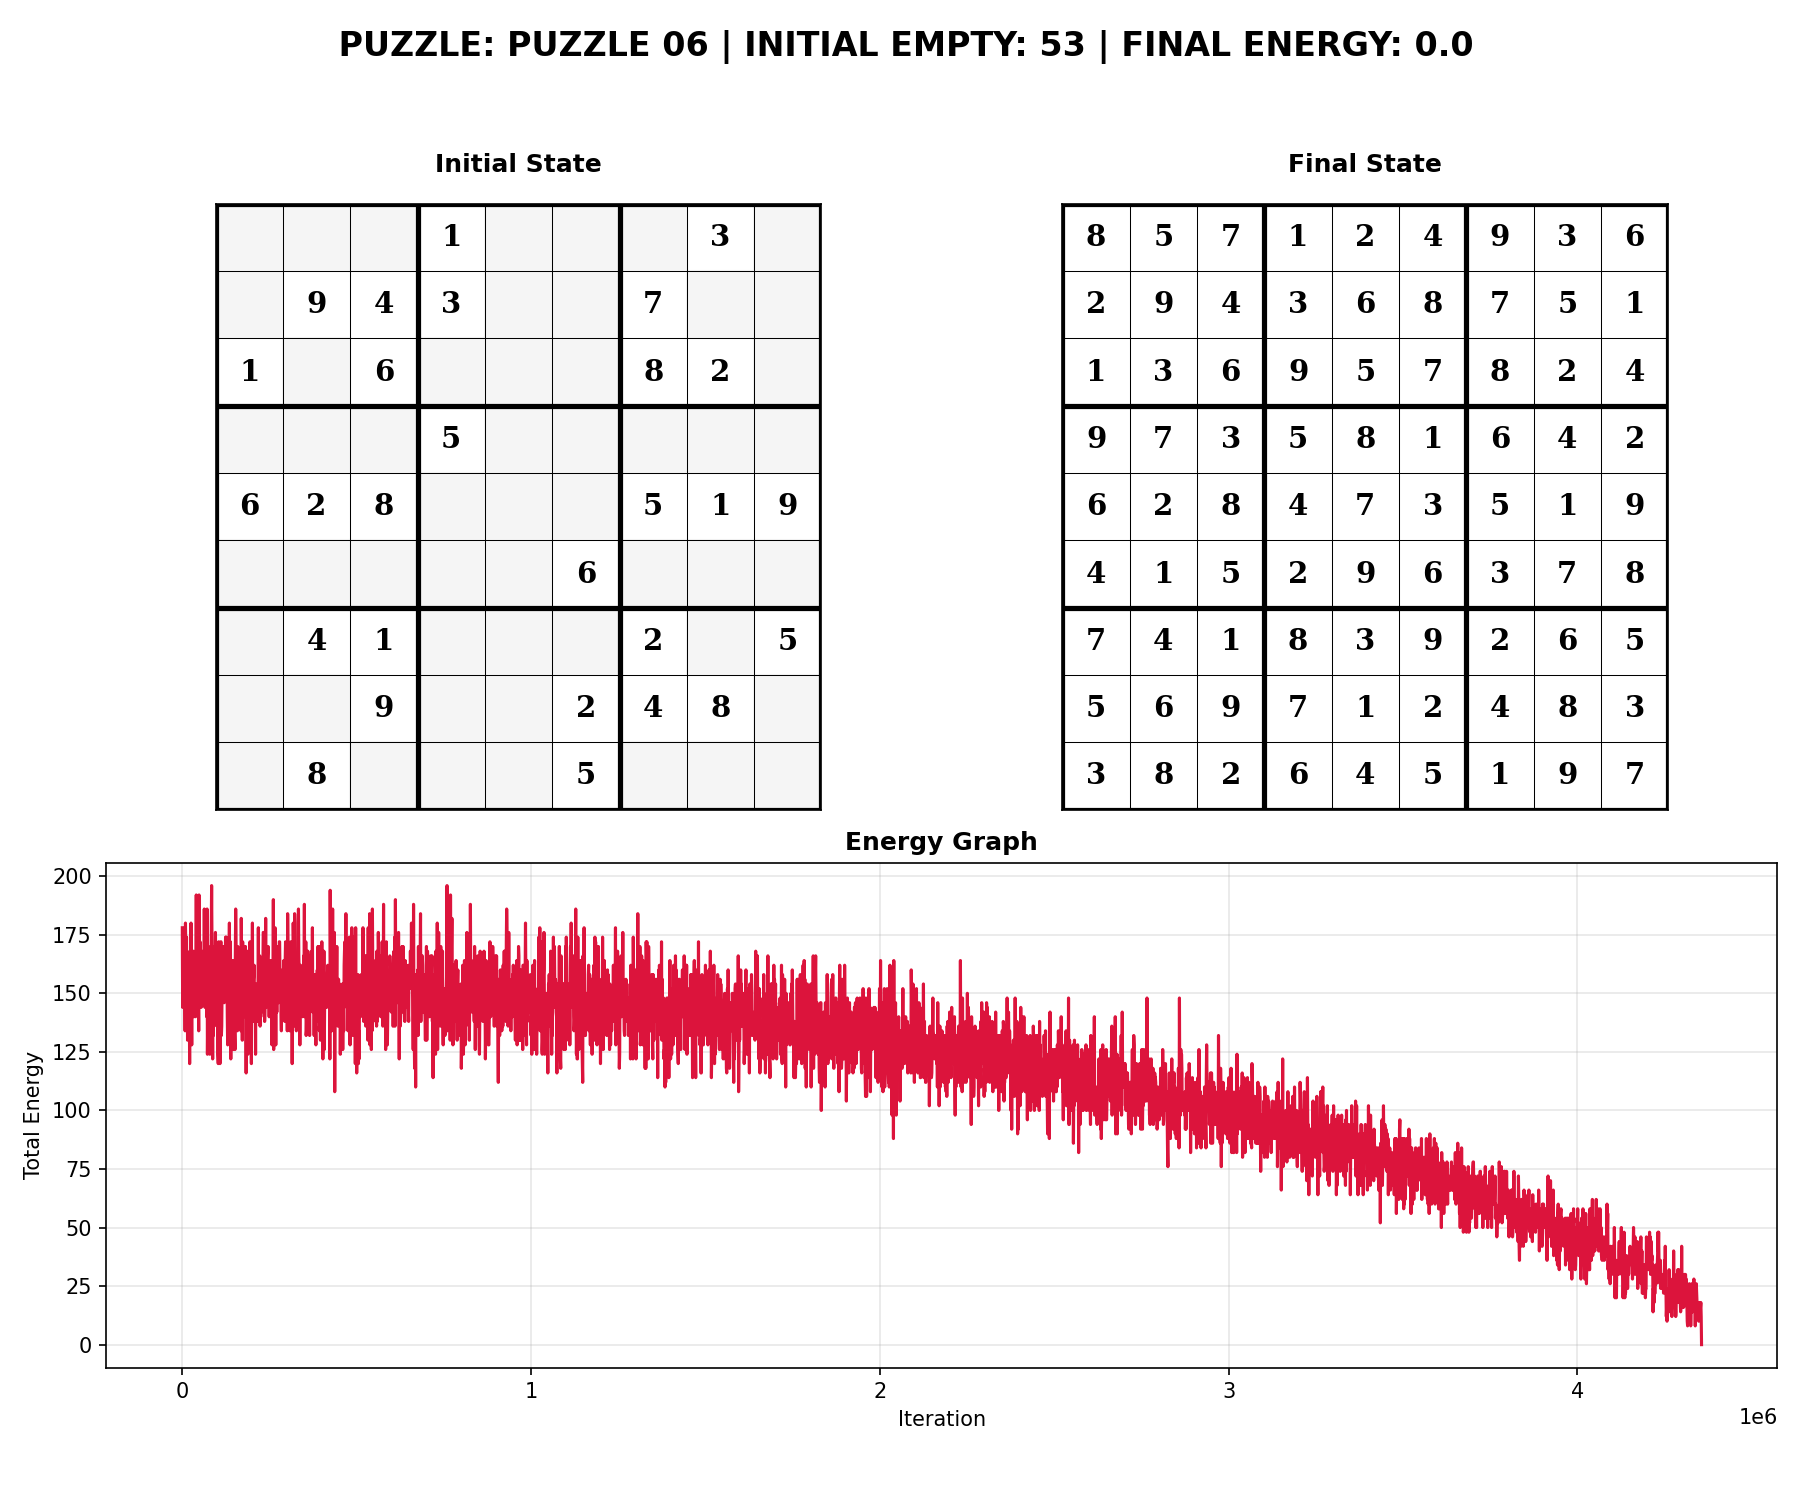

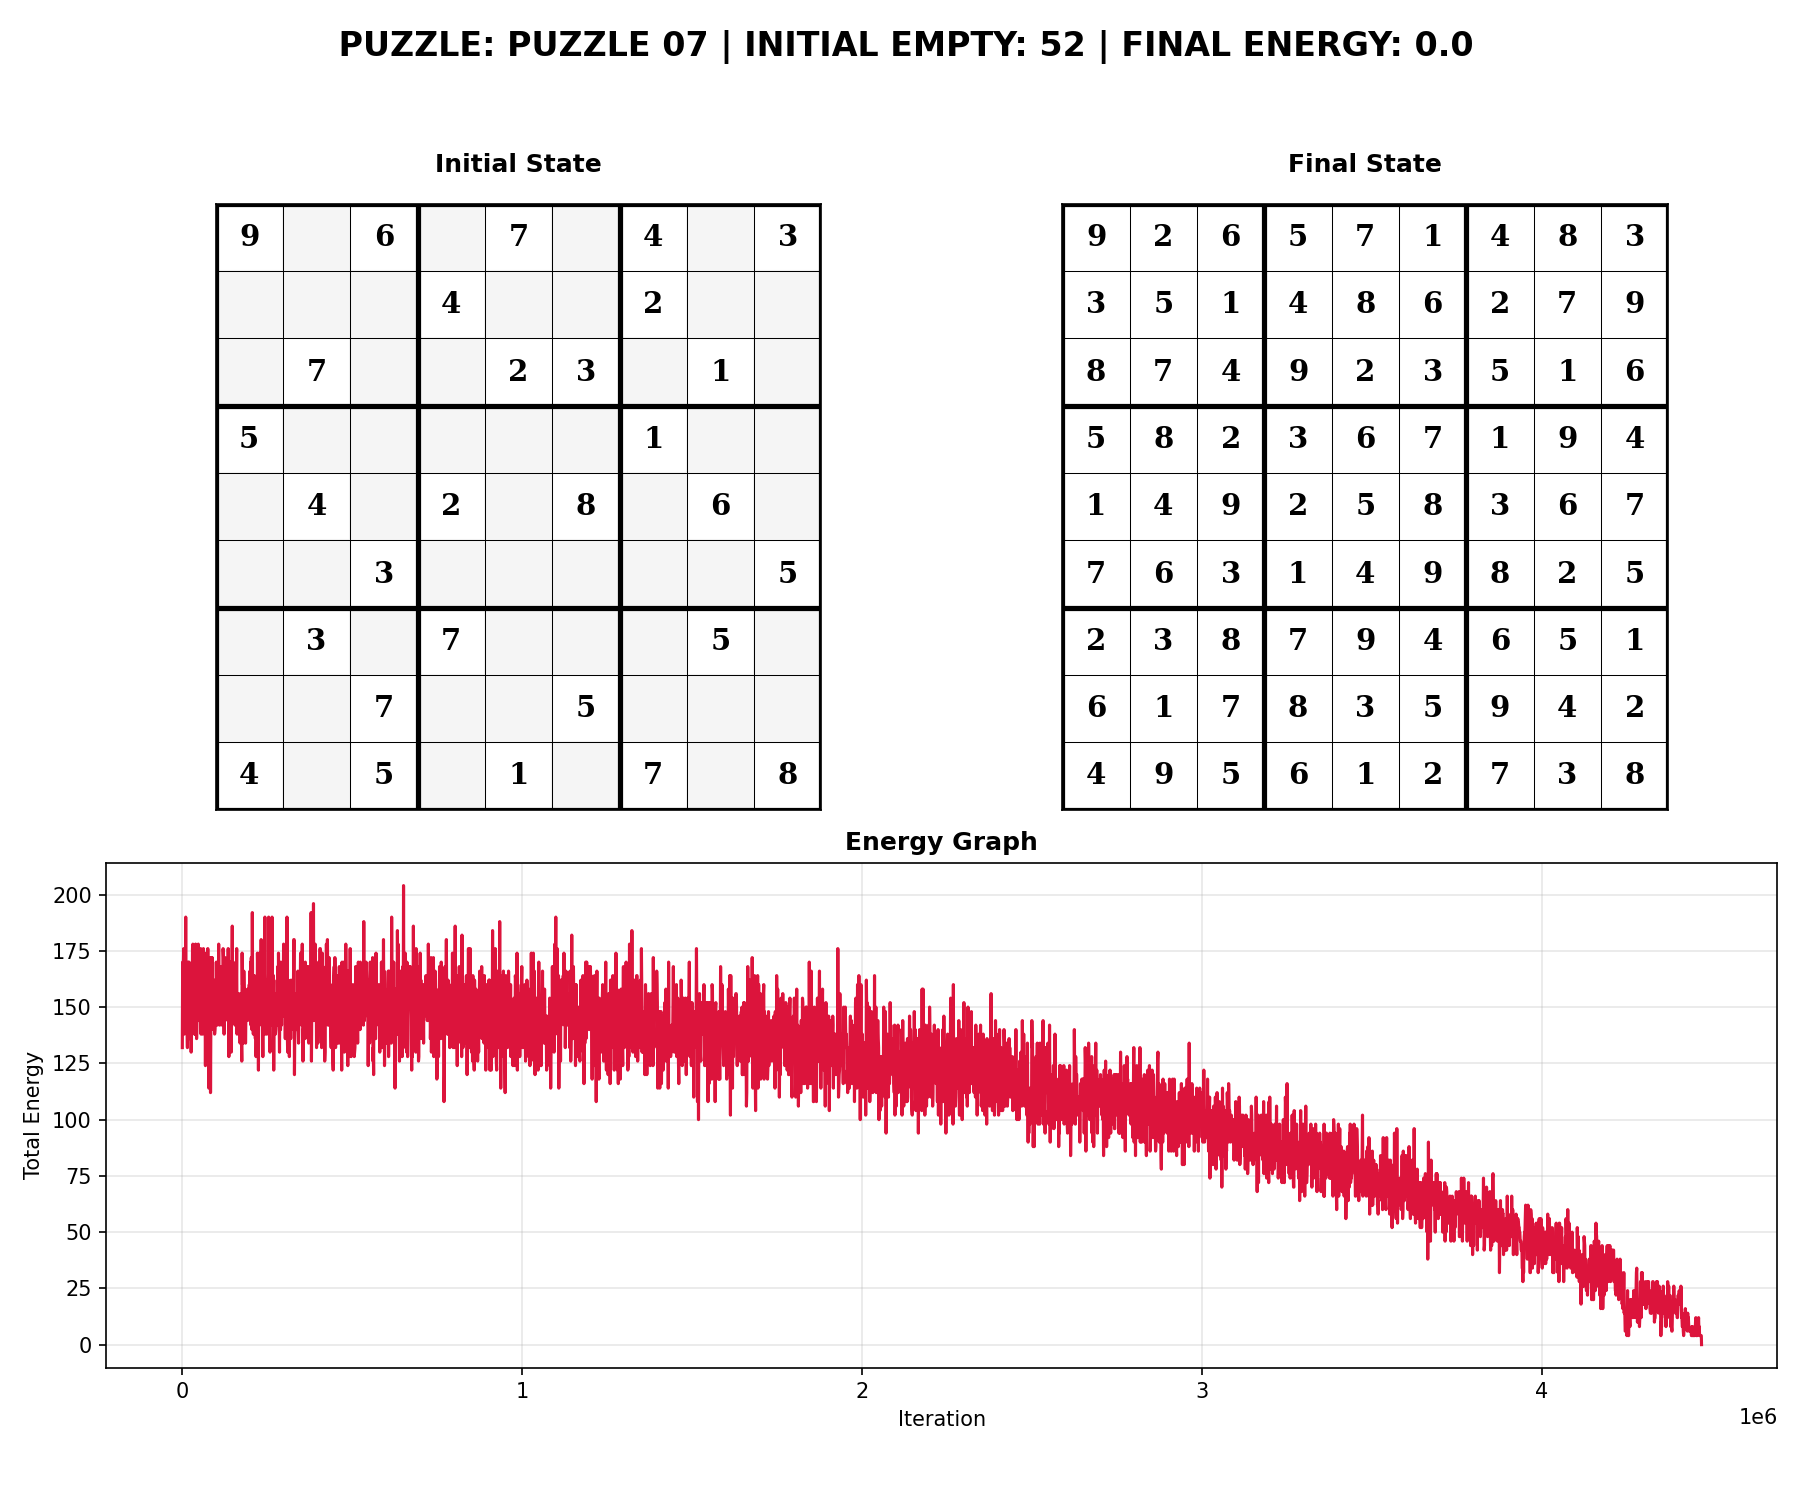

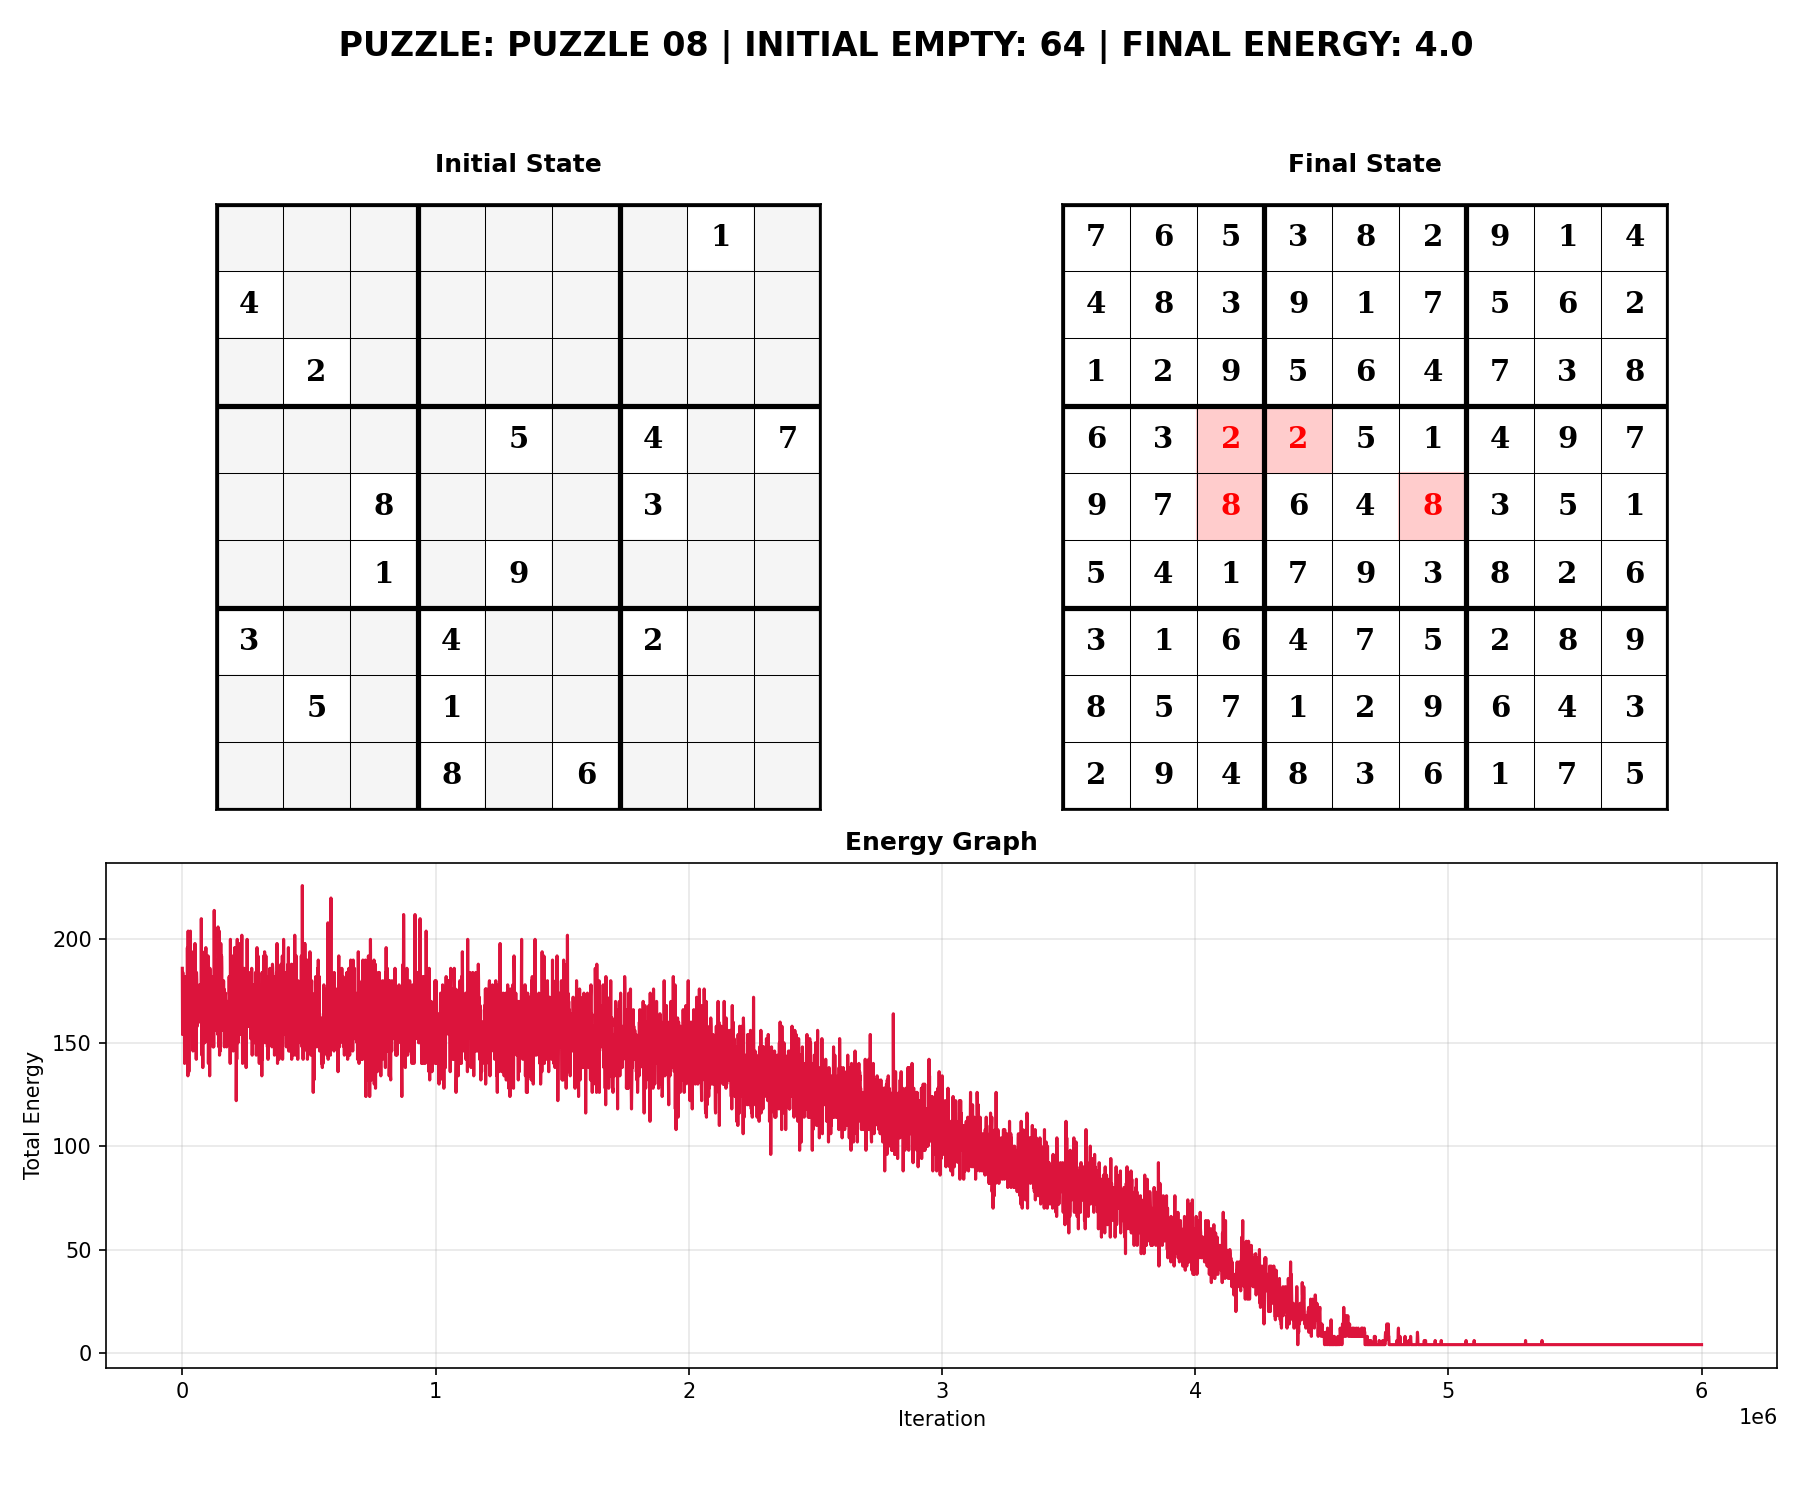

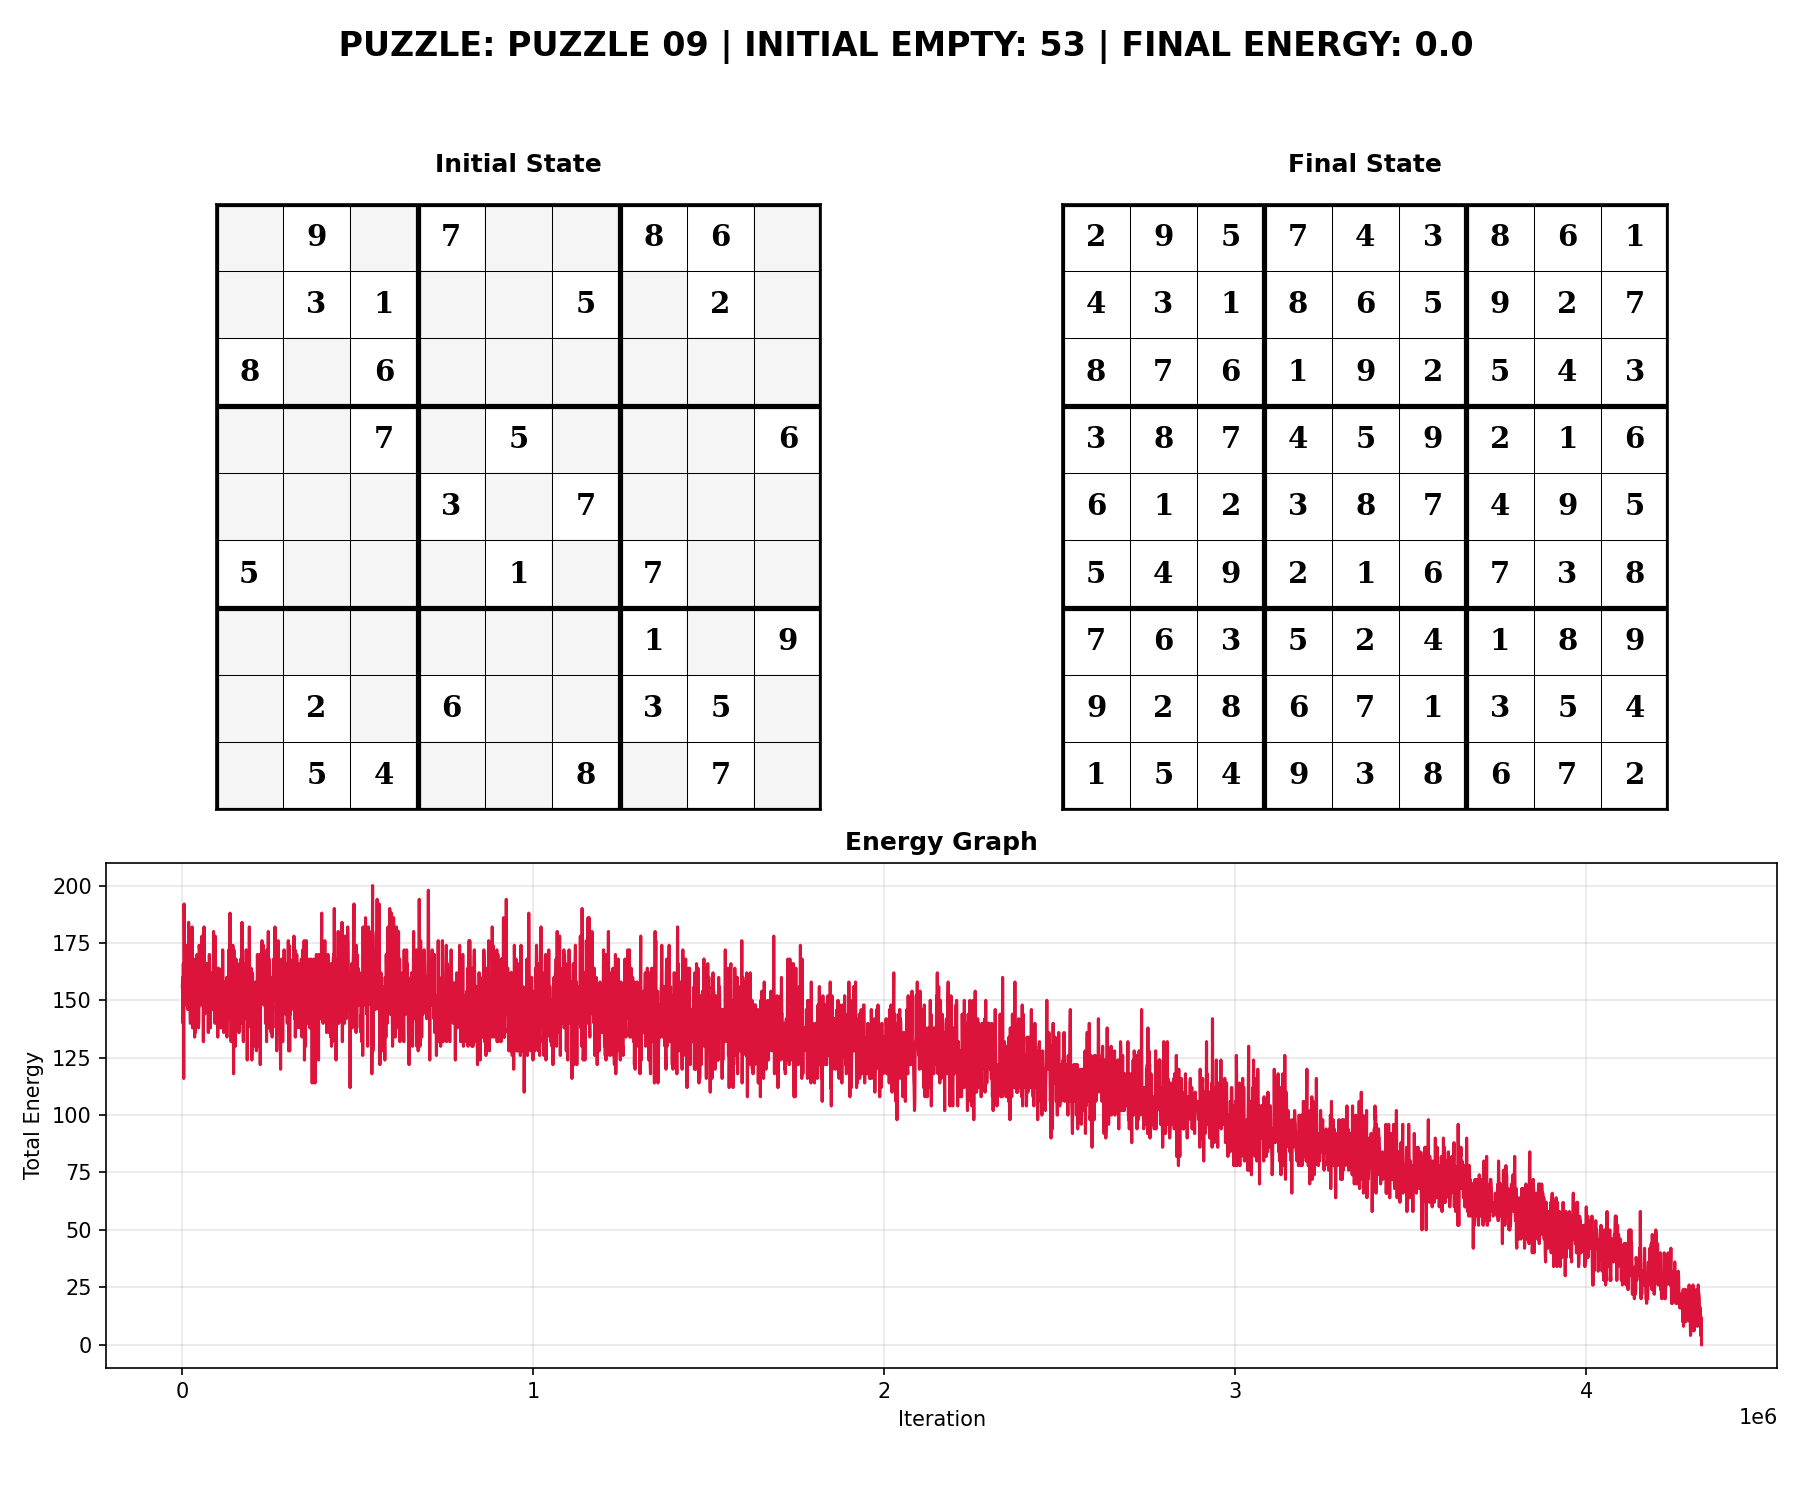

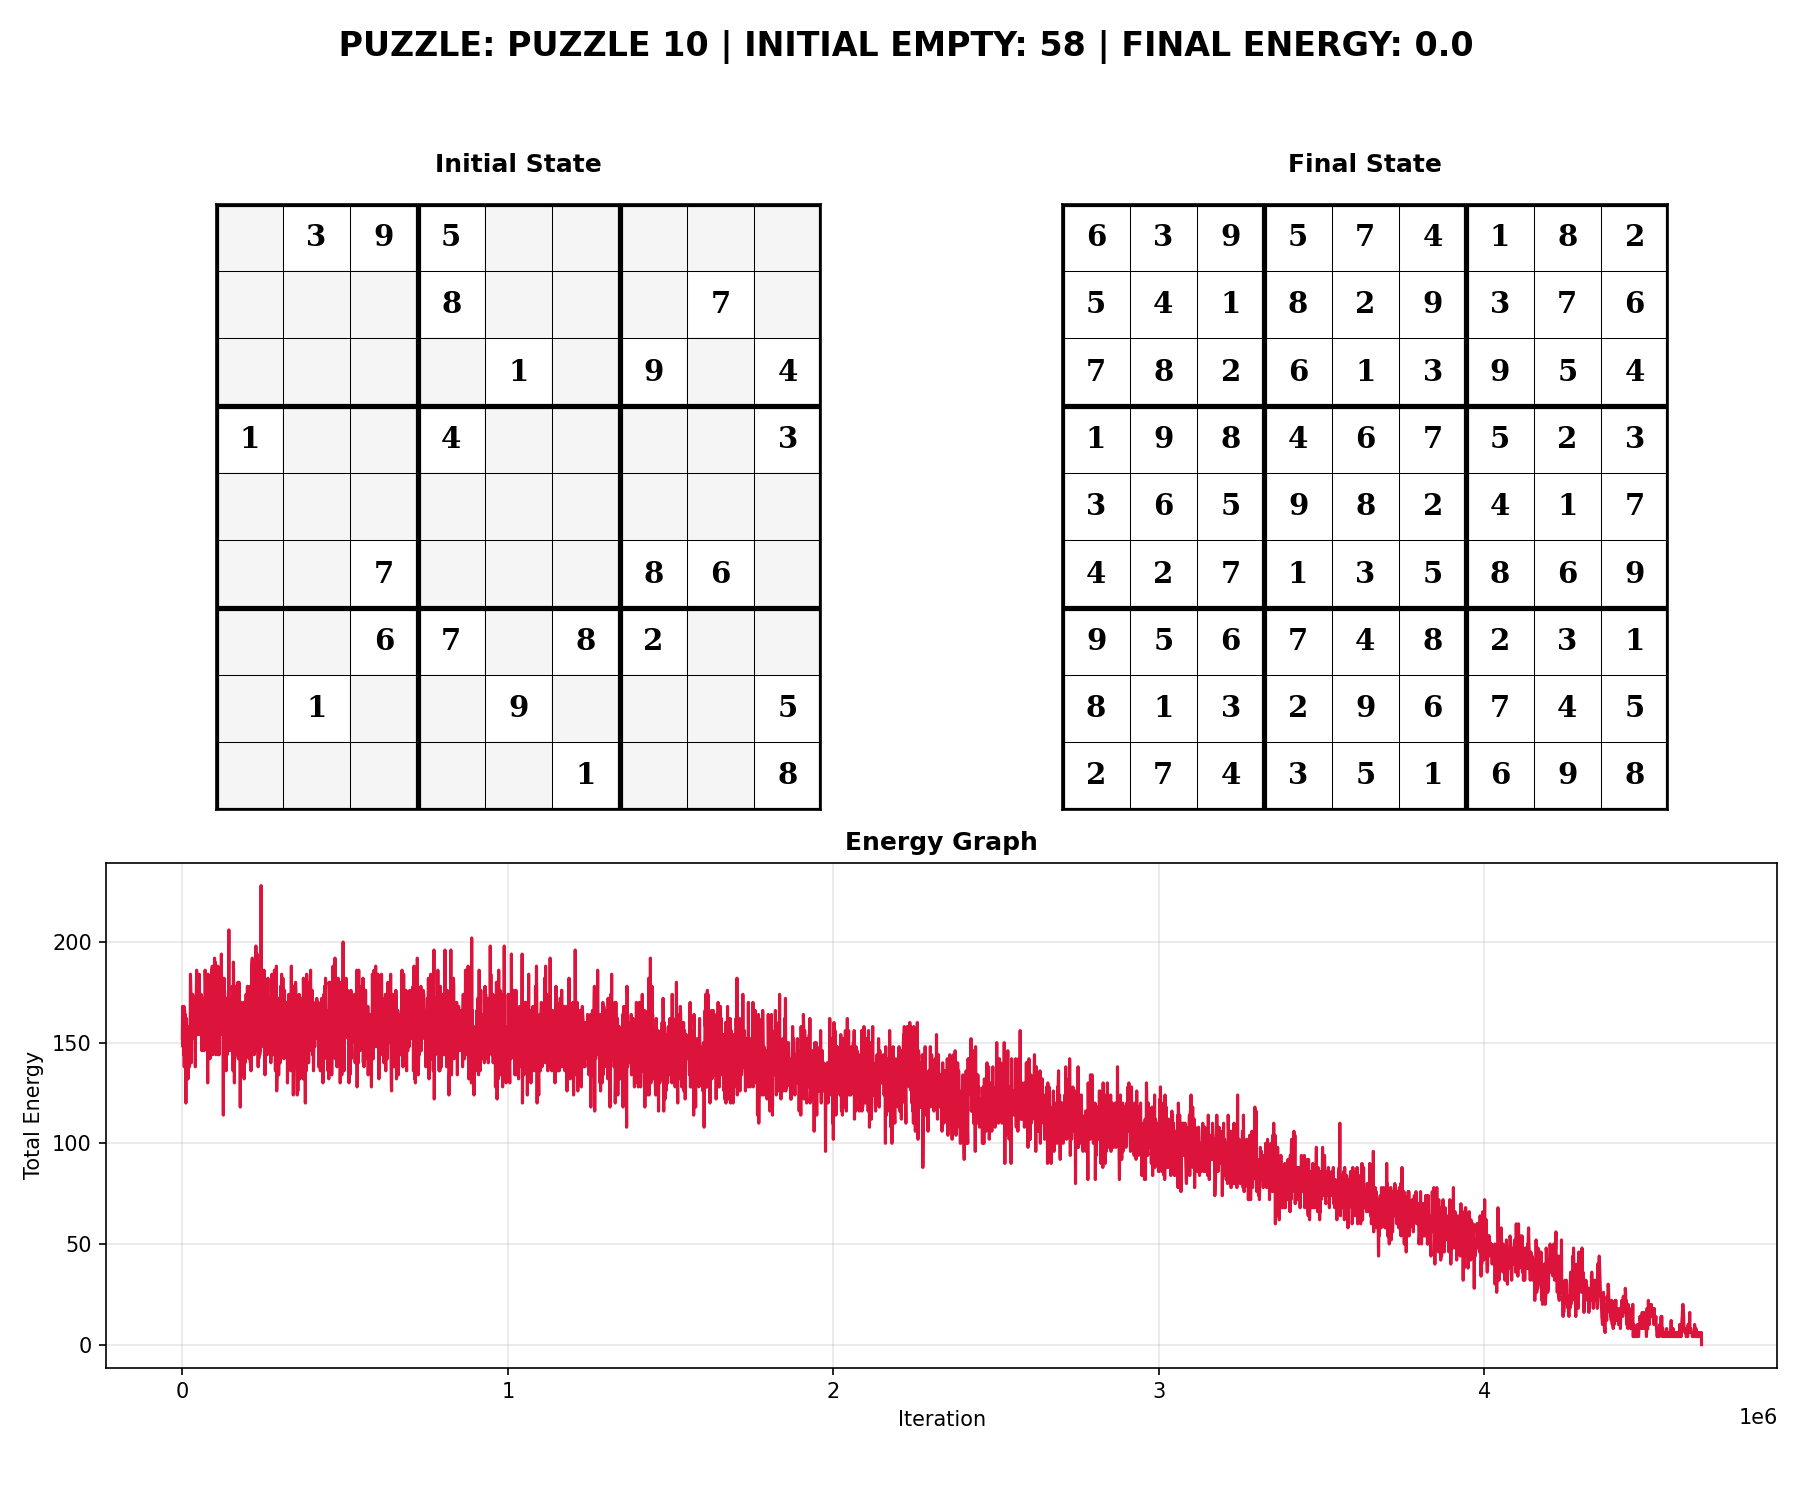

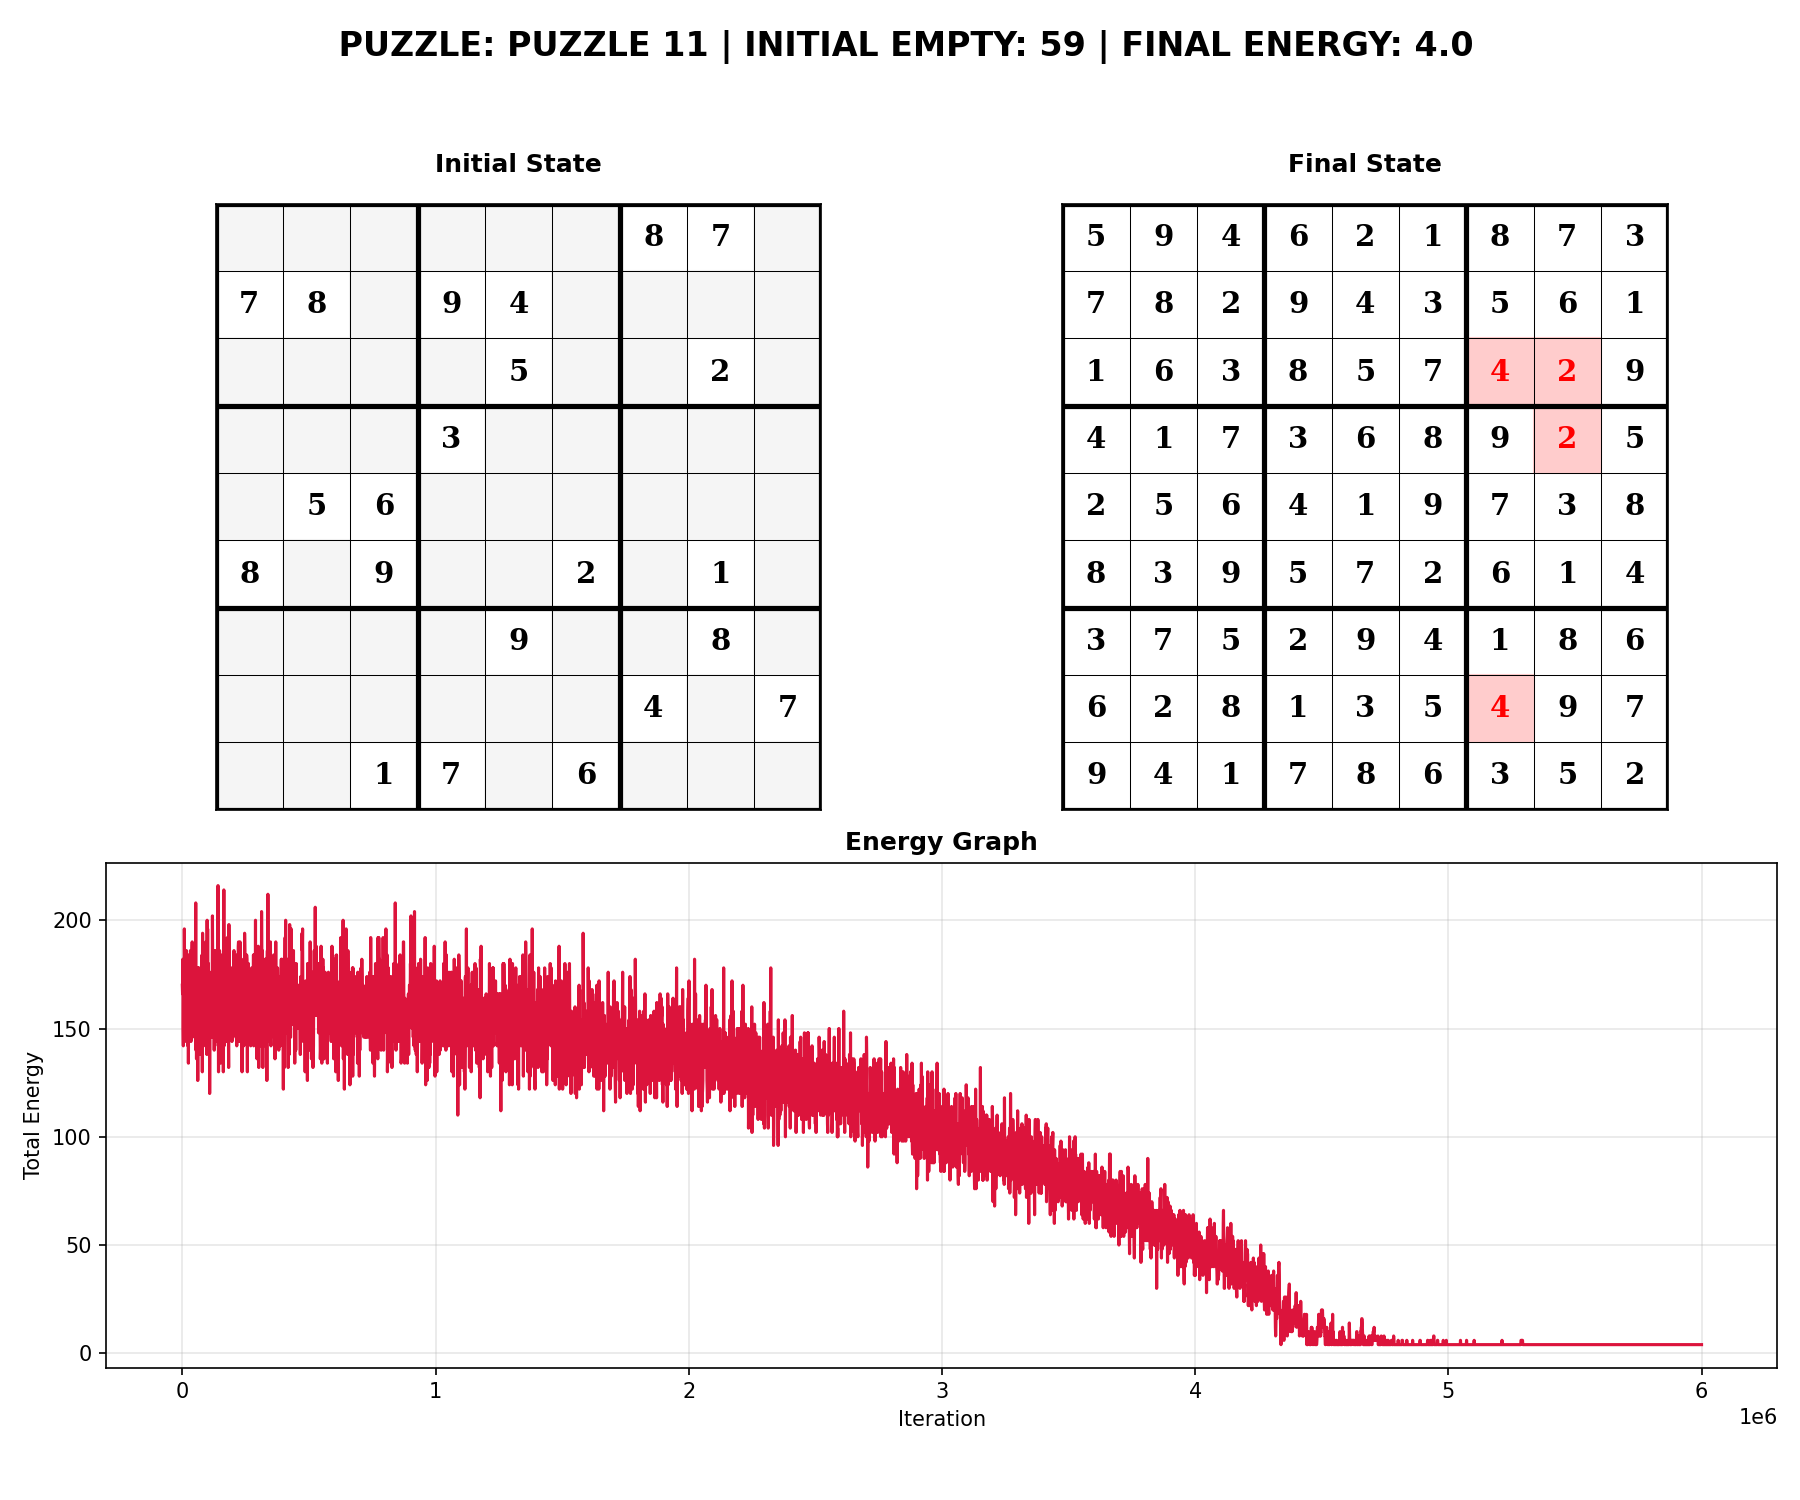

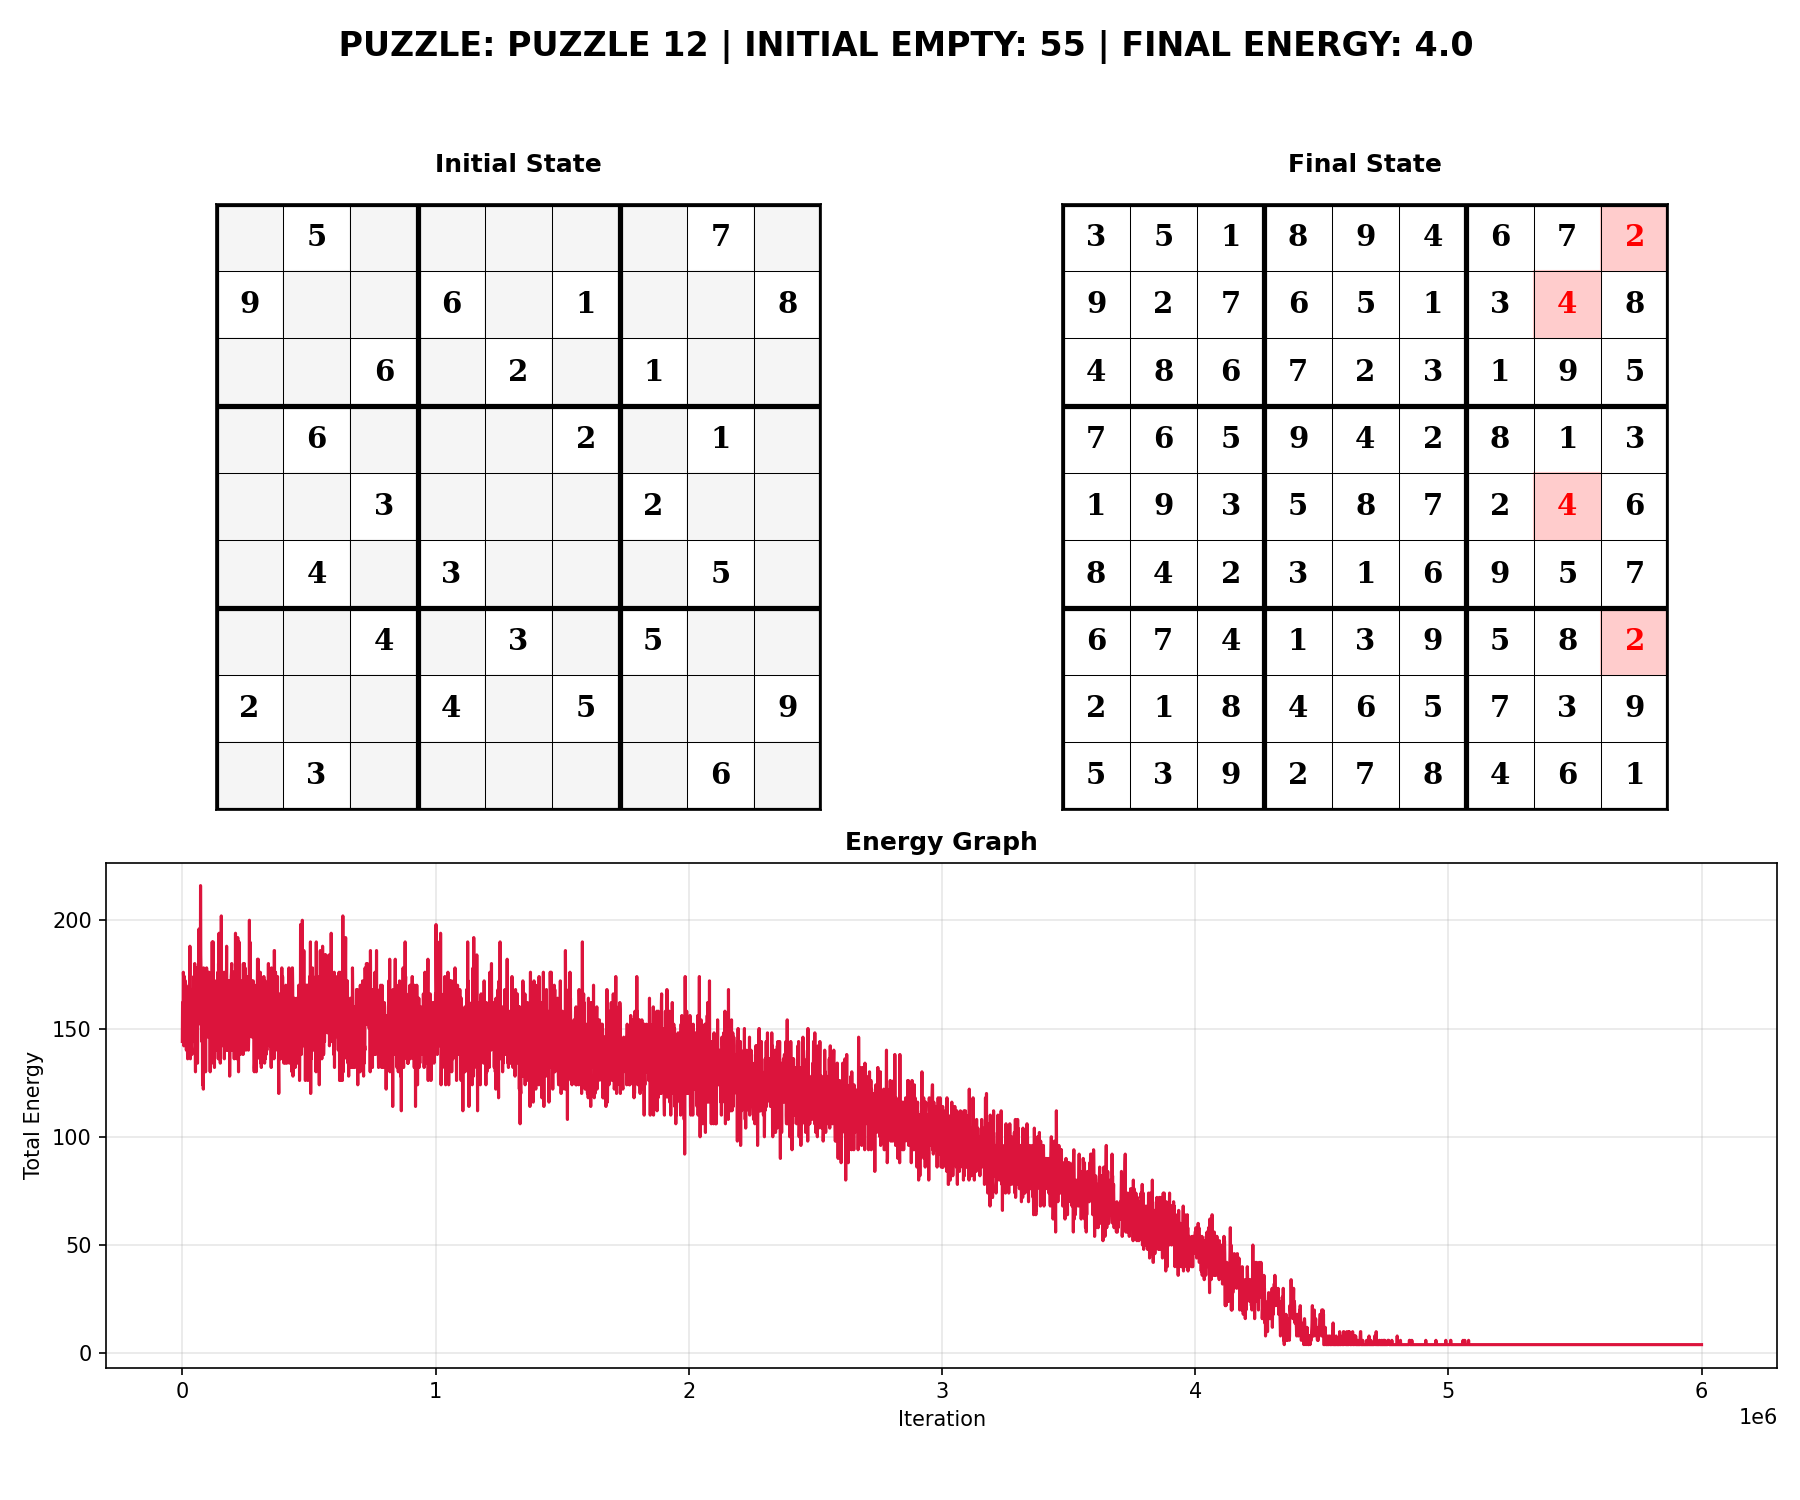

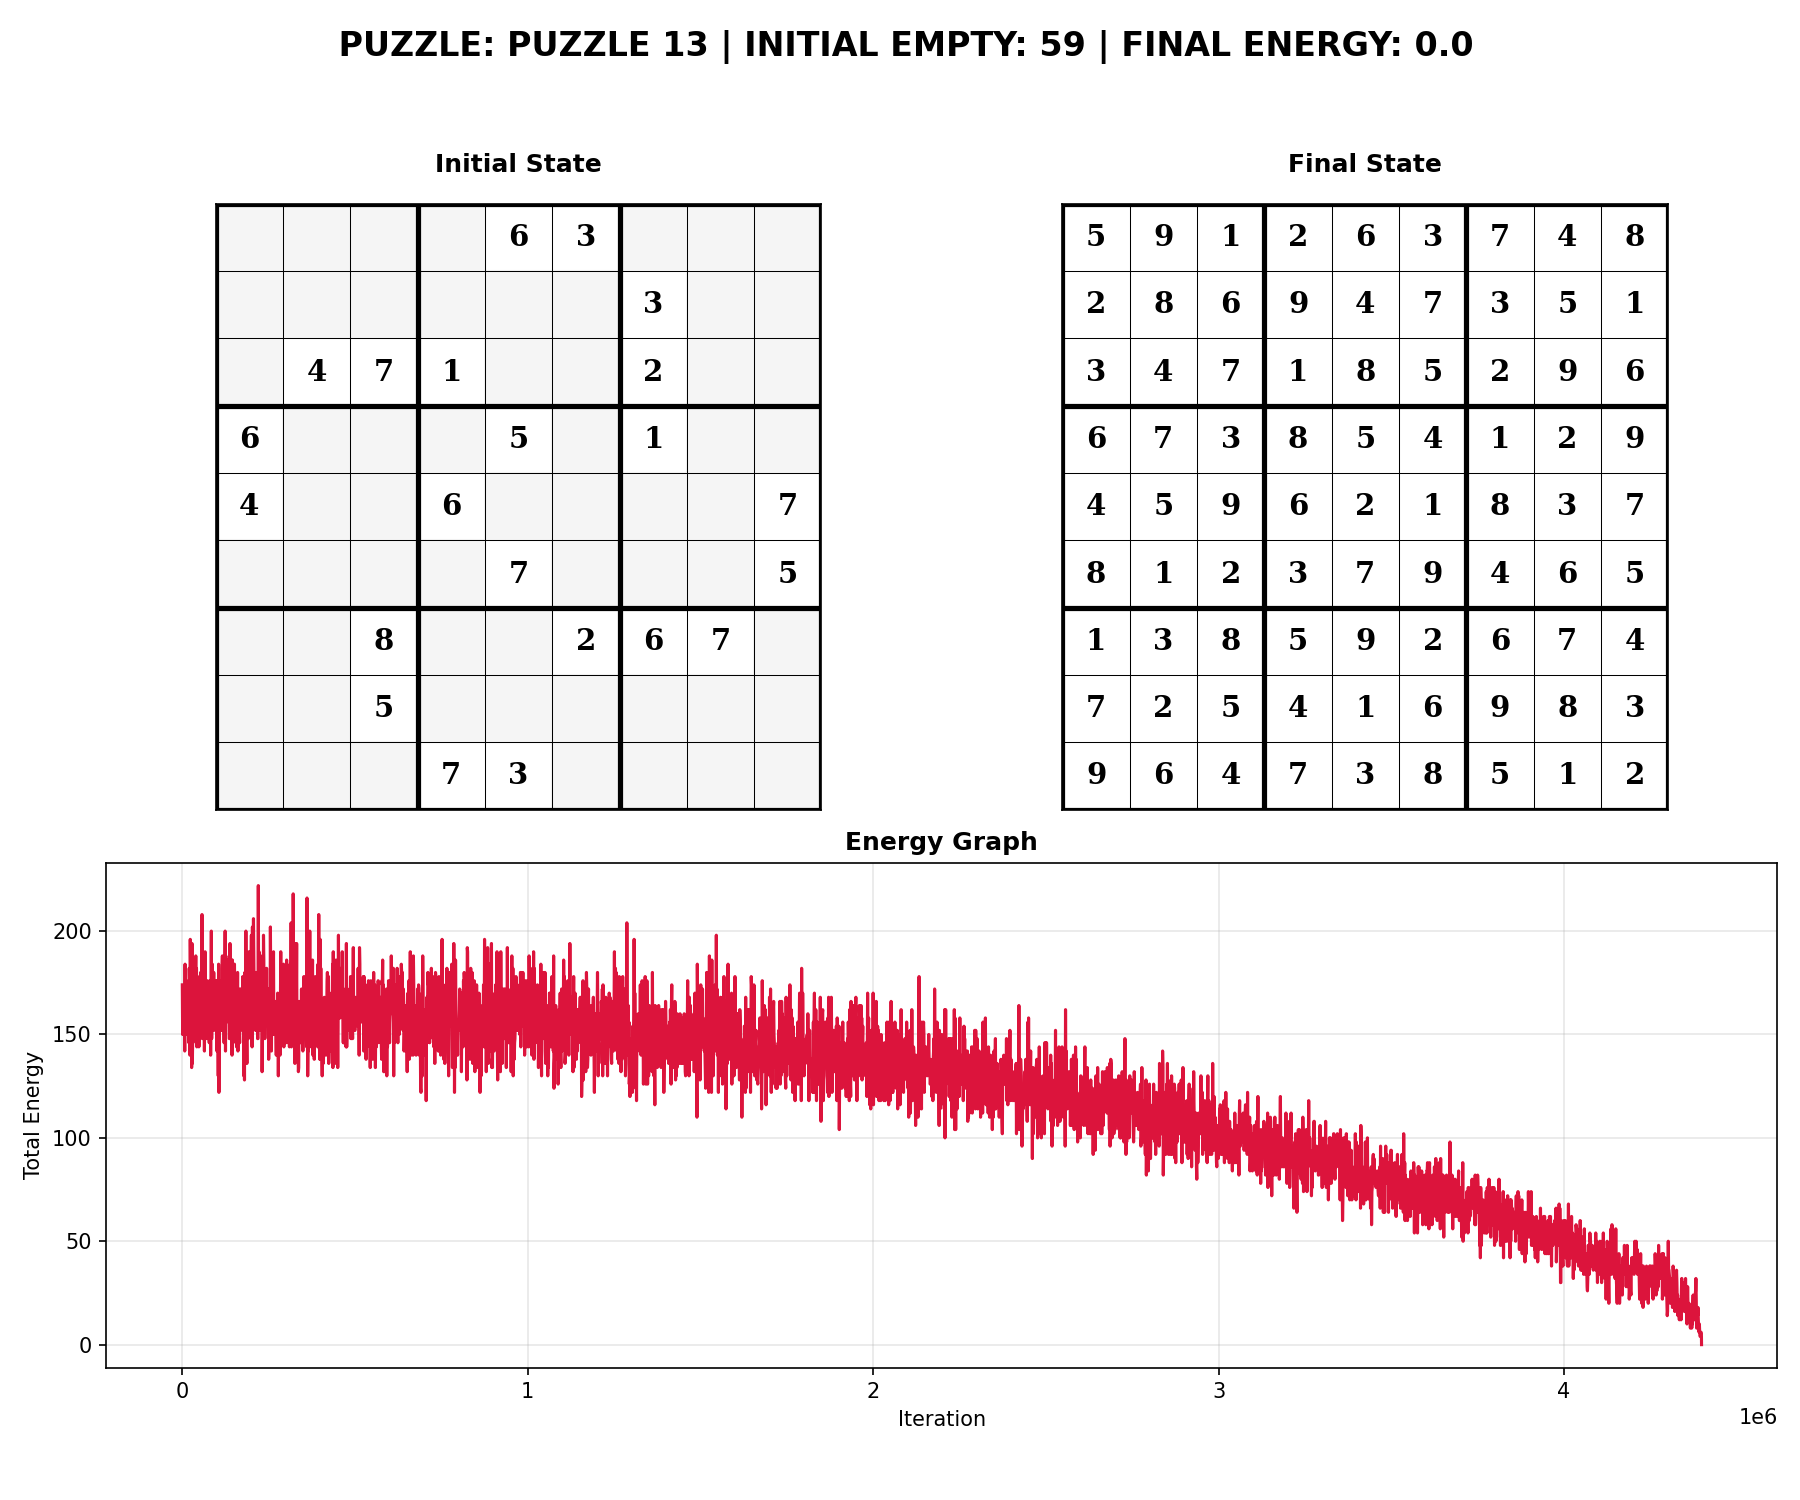

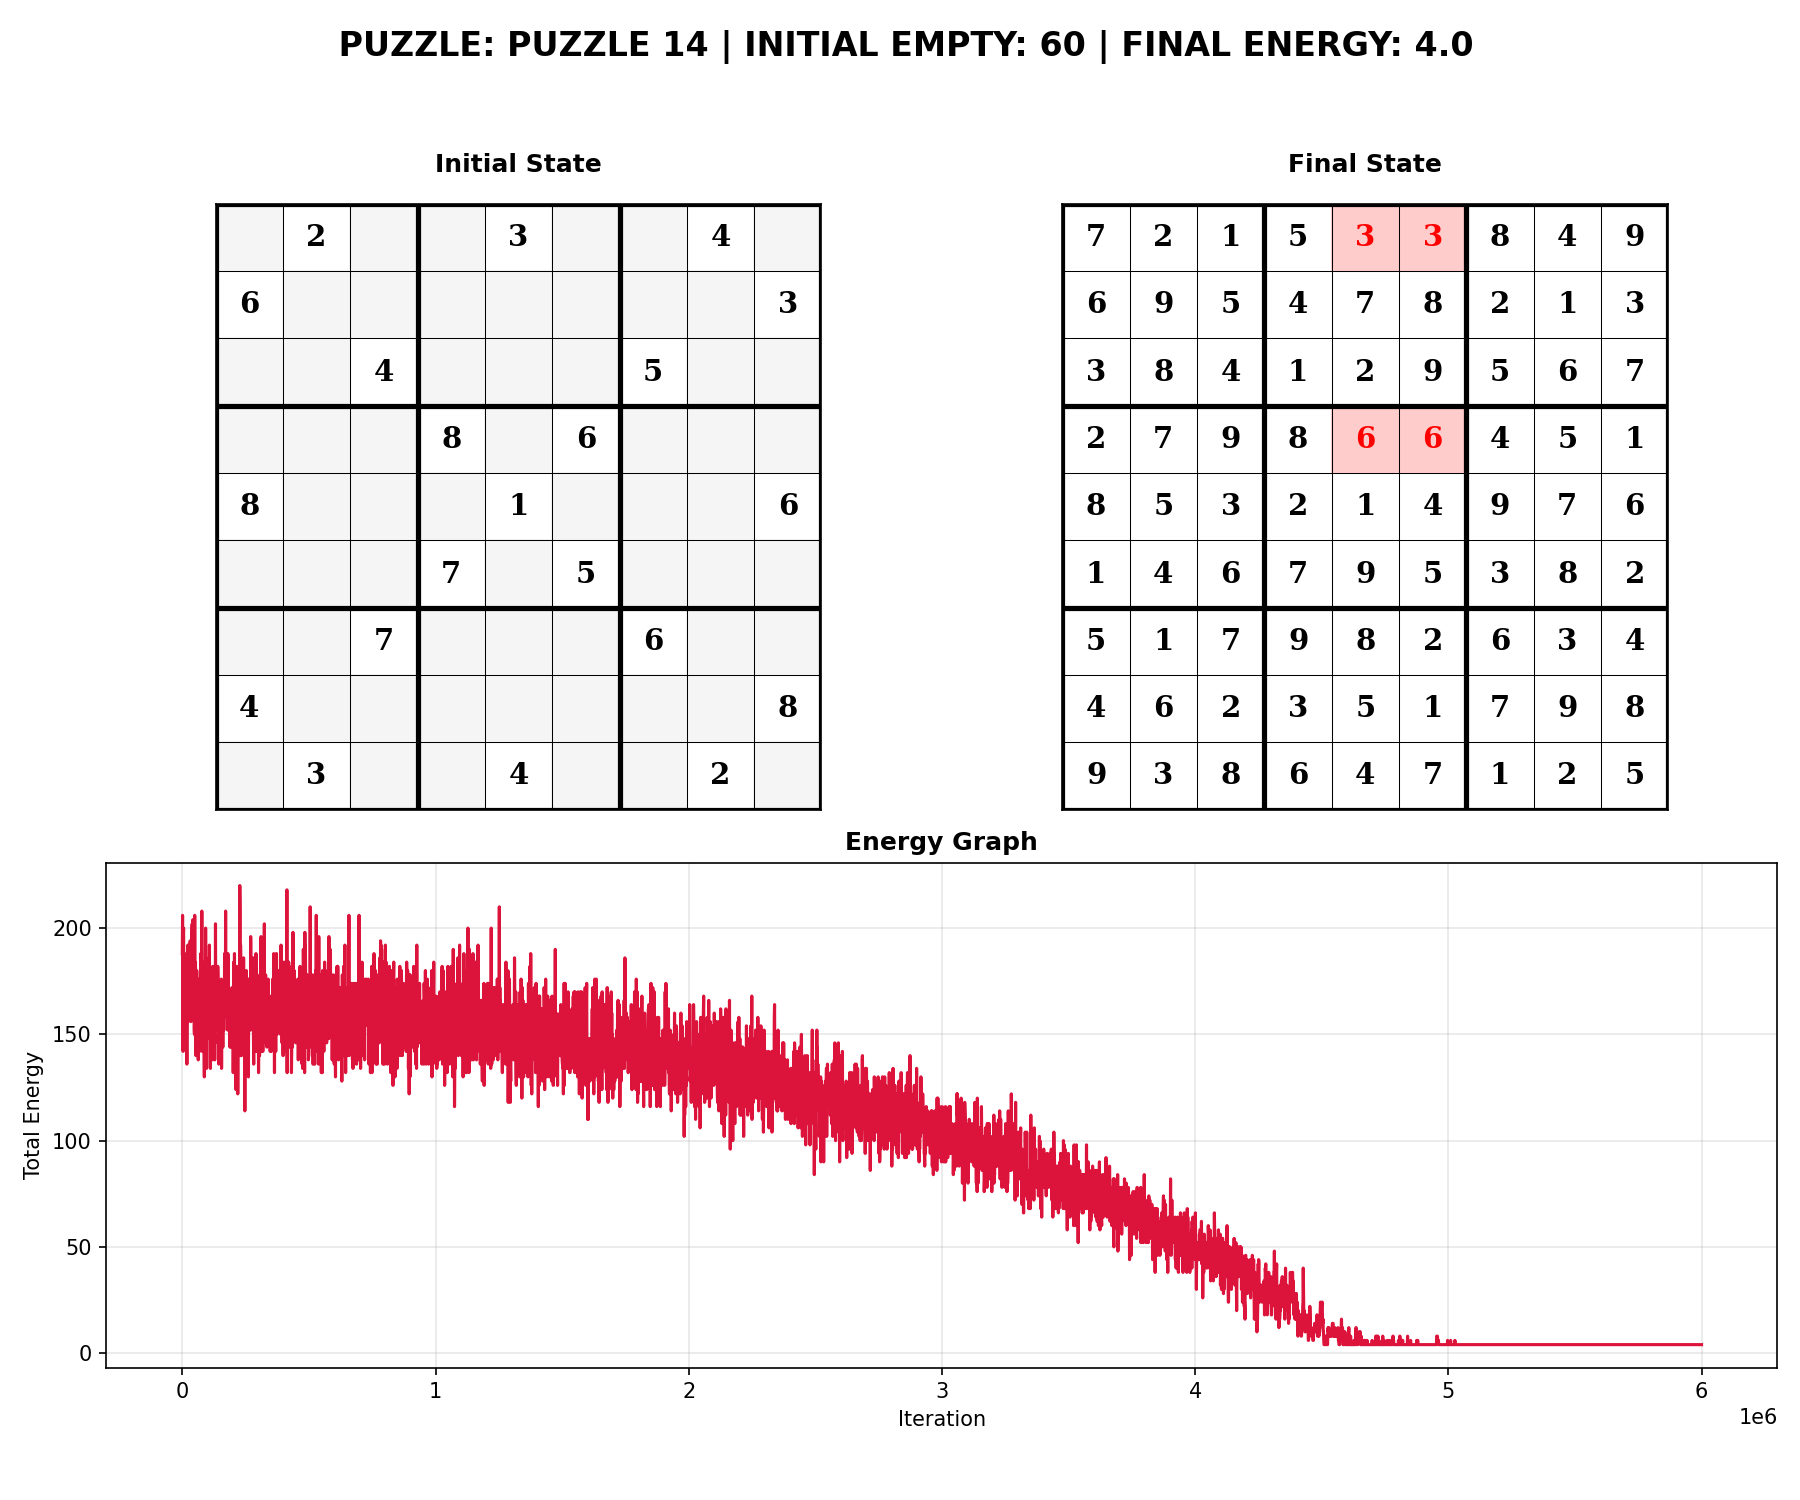

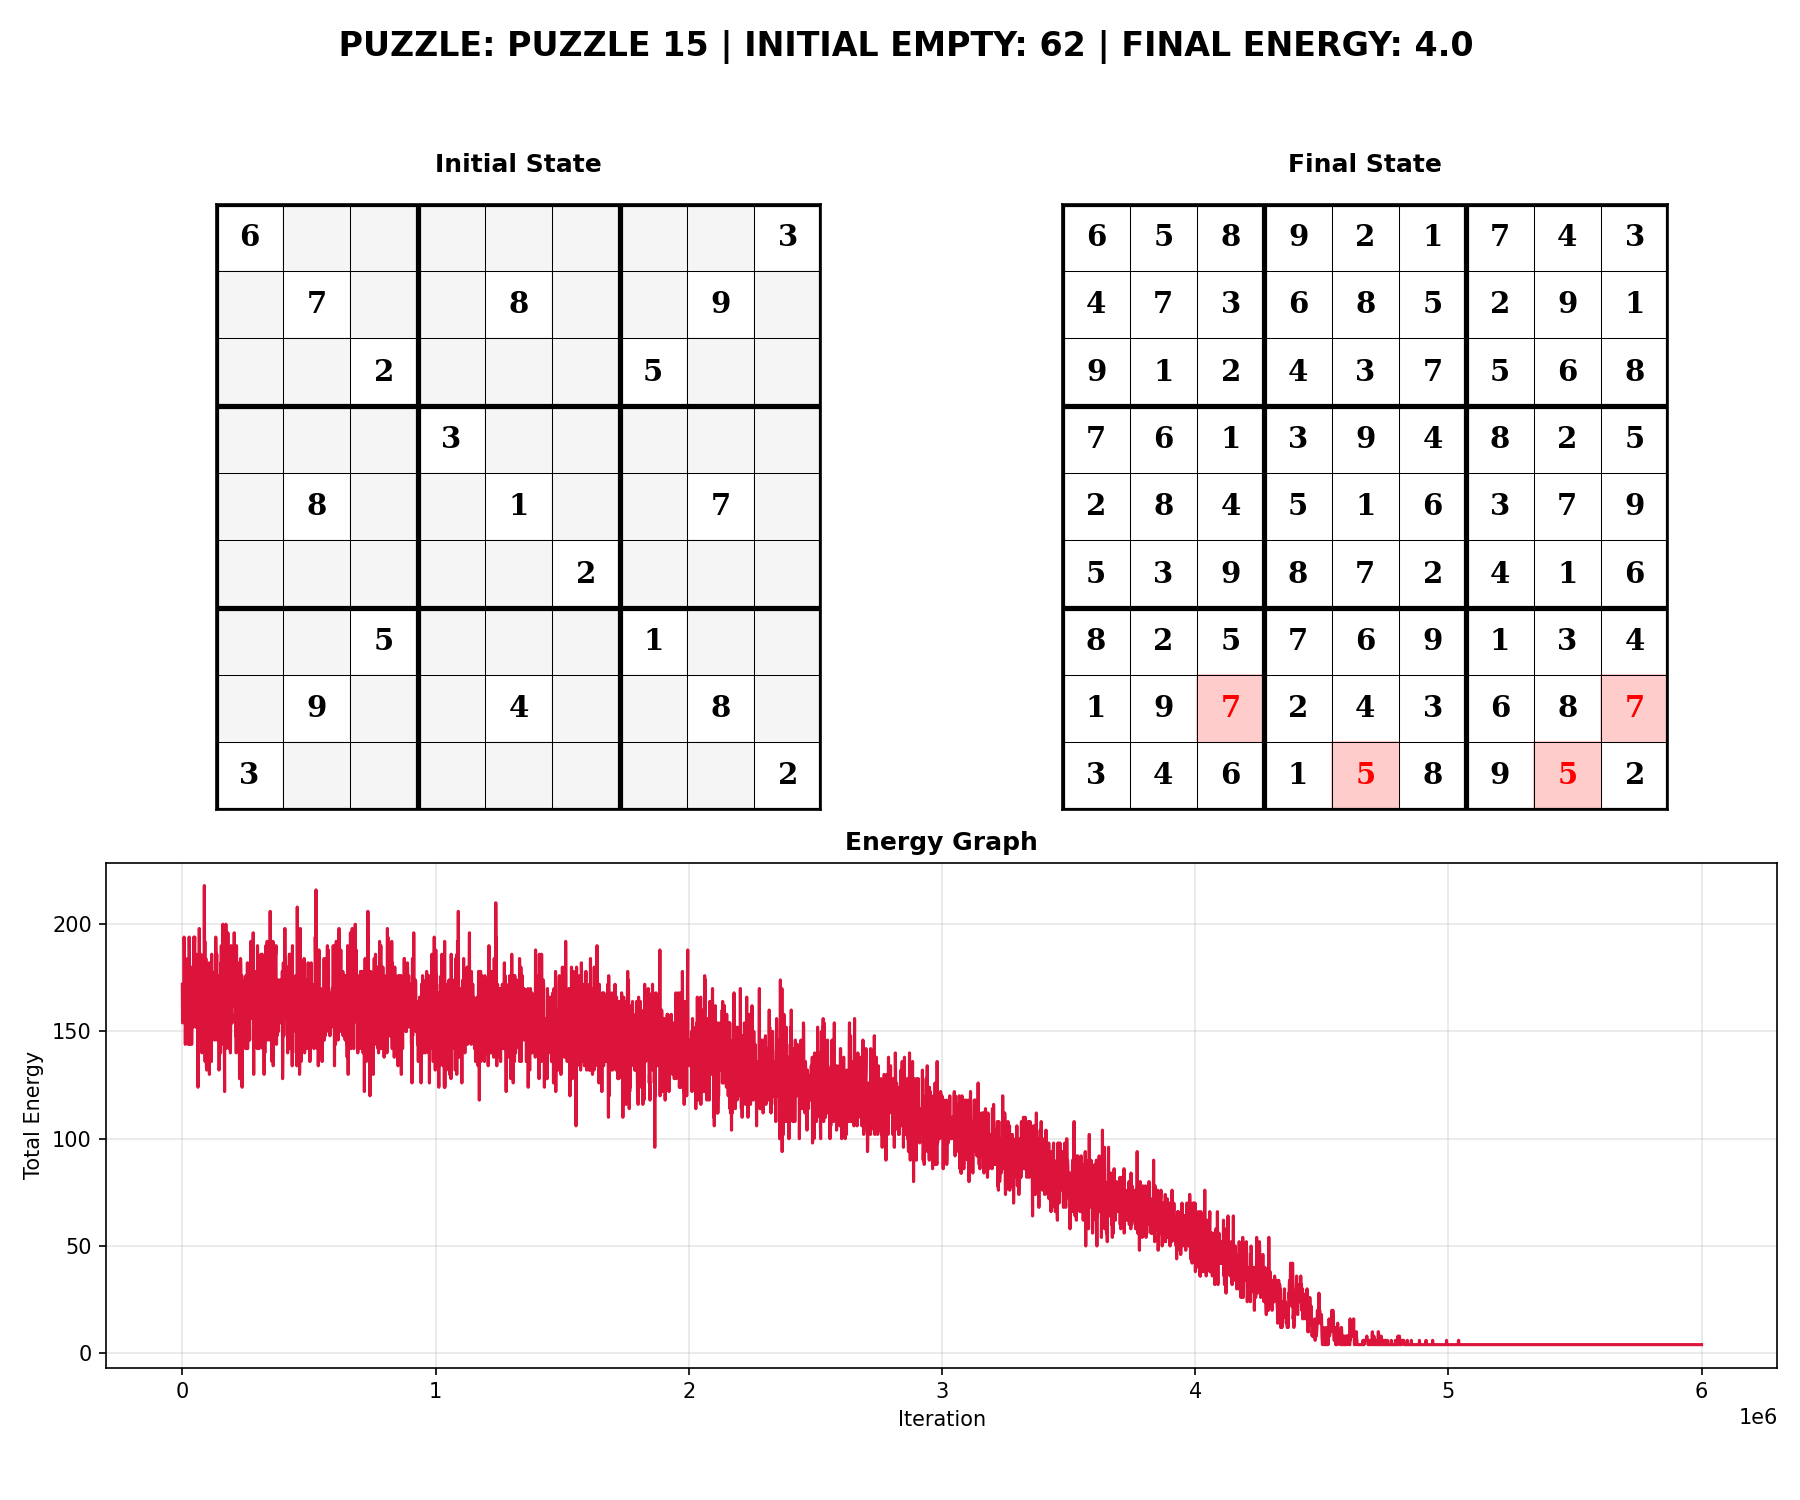

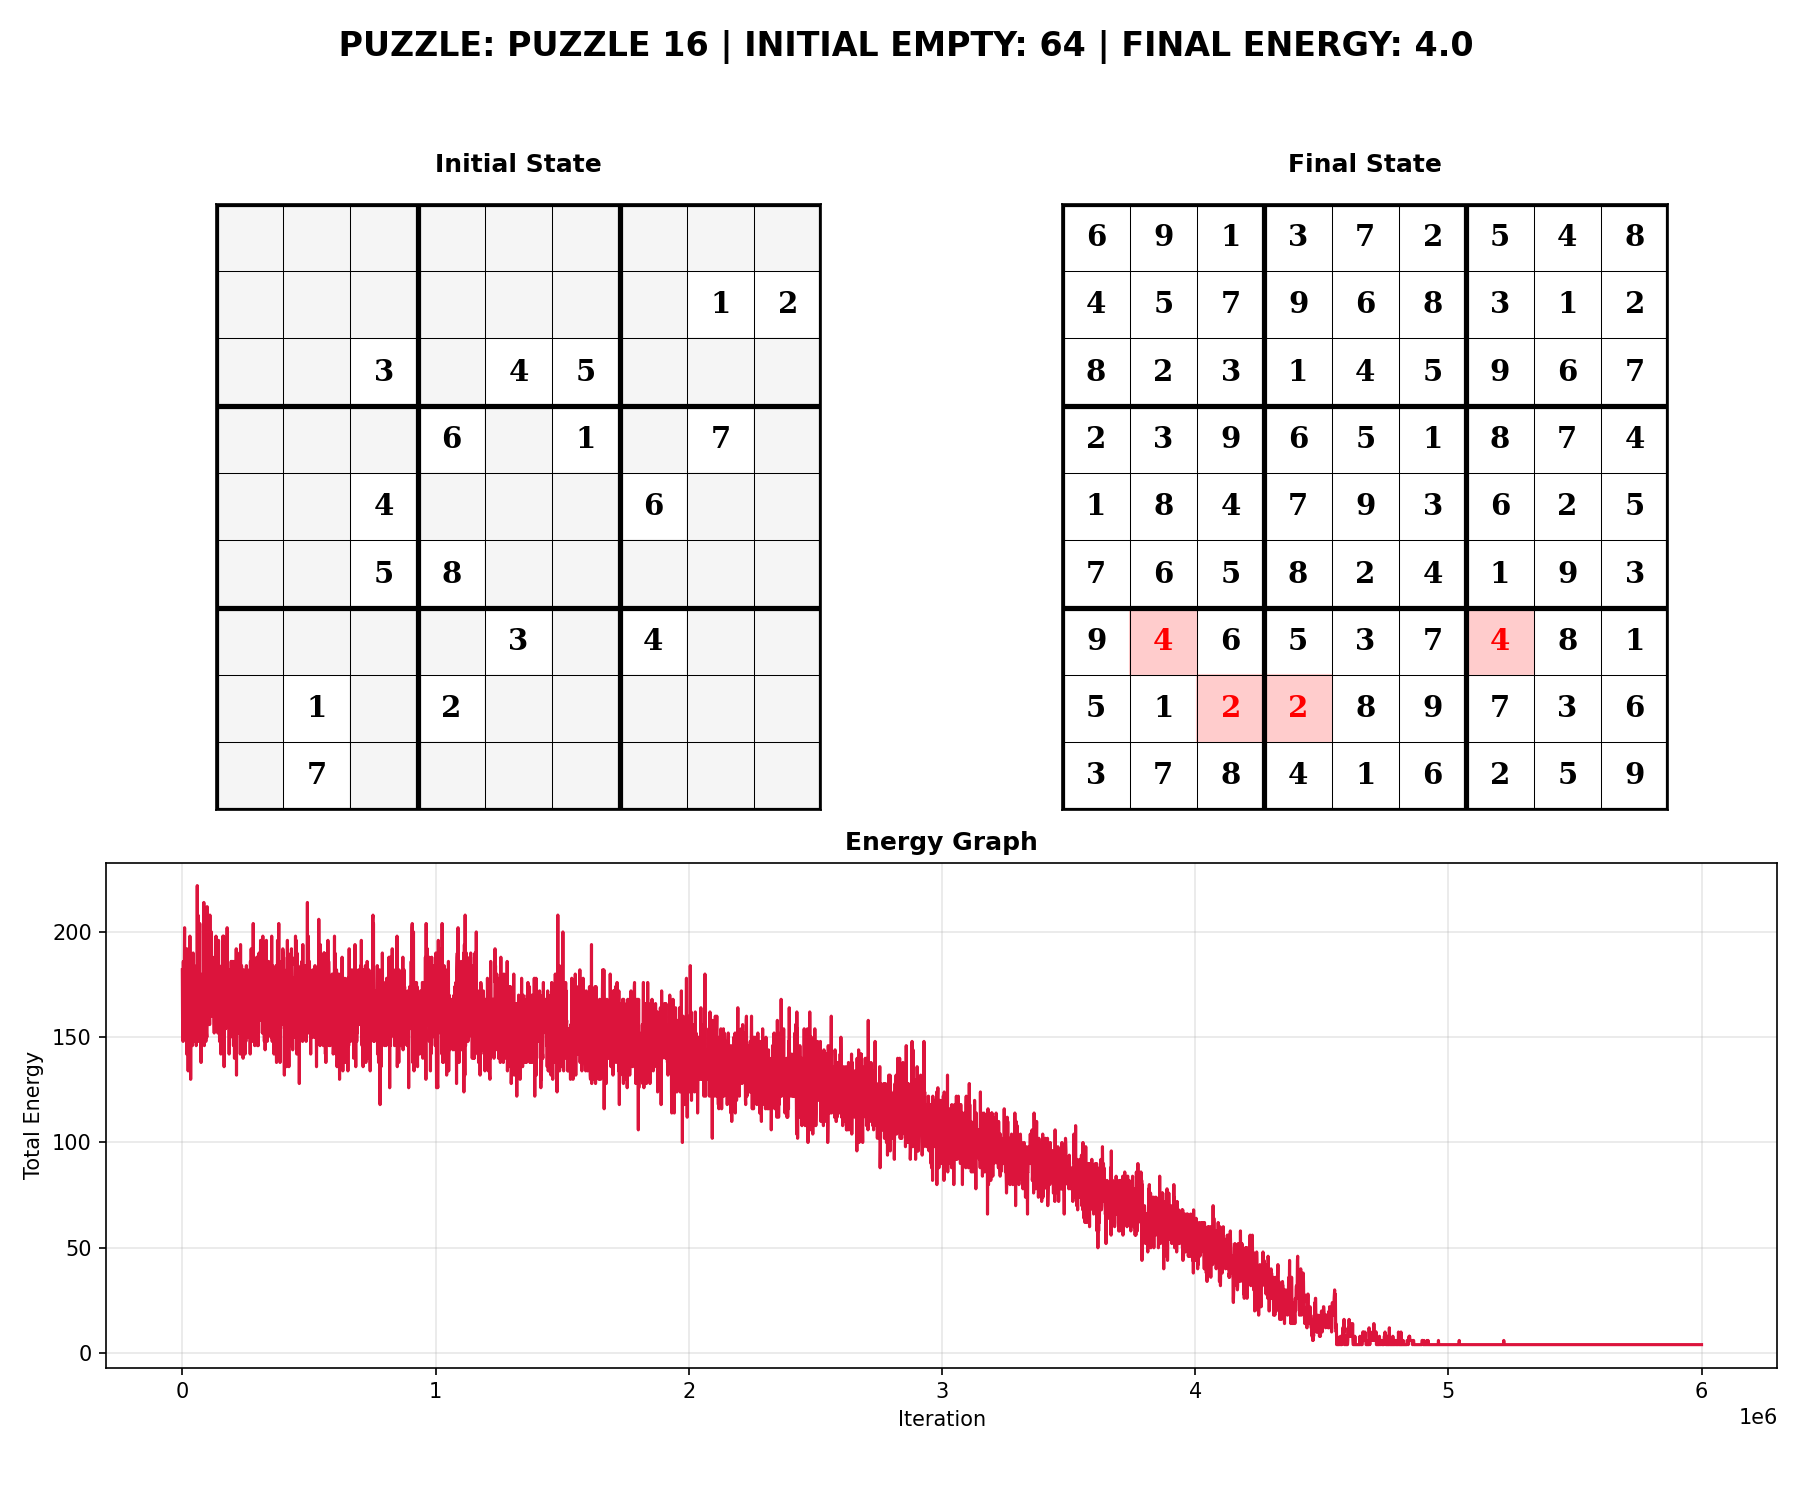

In [13]:
files = os.listdir("ok")
files.sort()

for file in files:
    if file != "performance.png":
        display(Image(f"ok/{file}"))

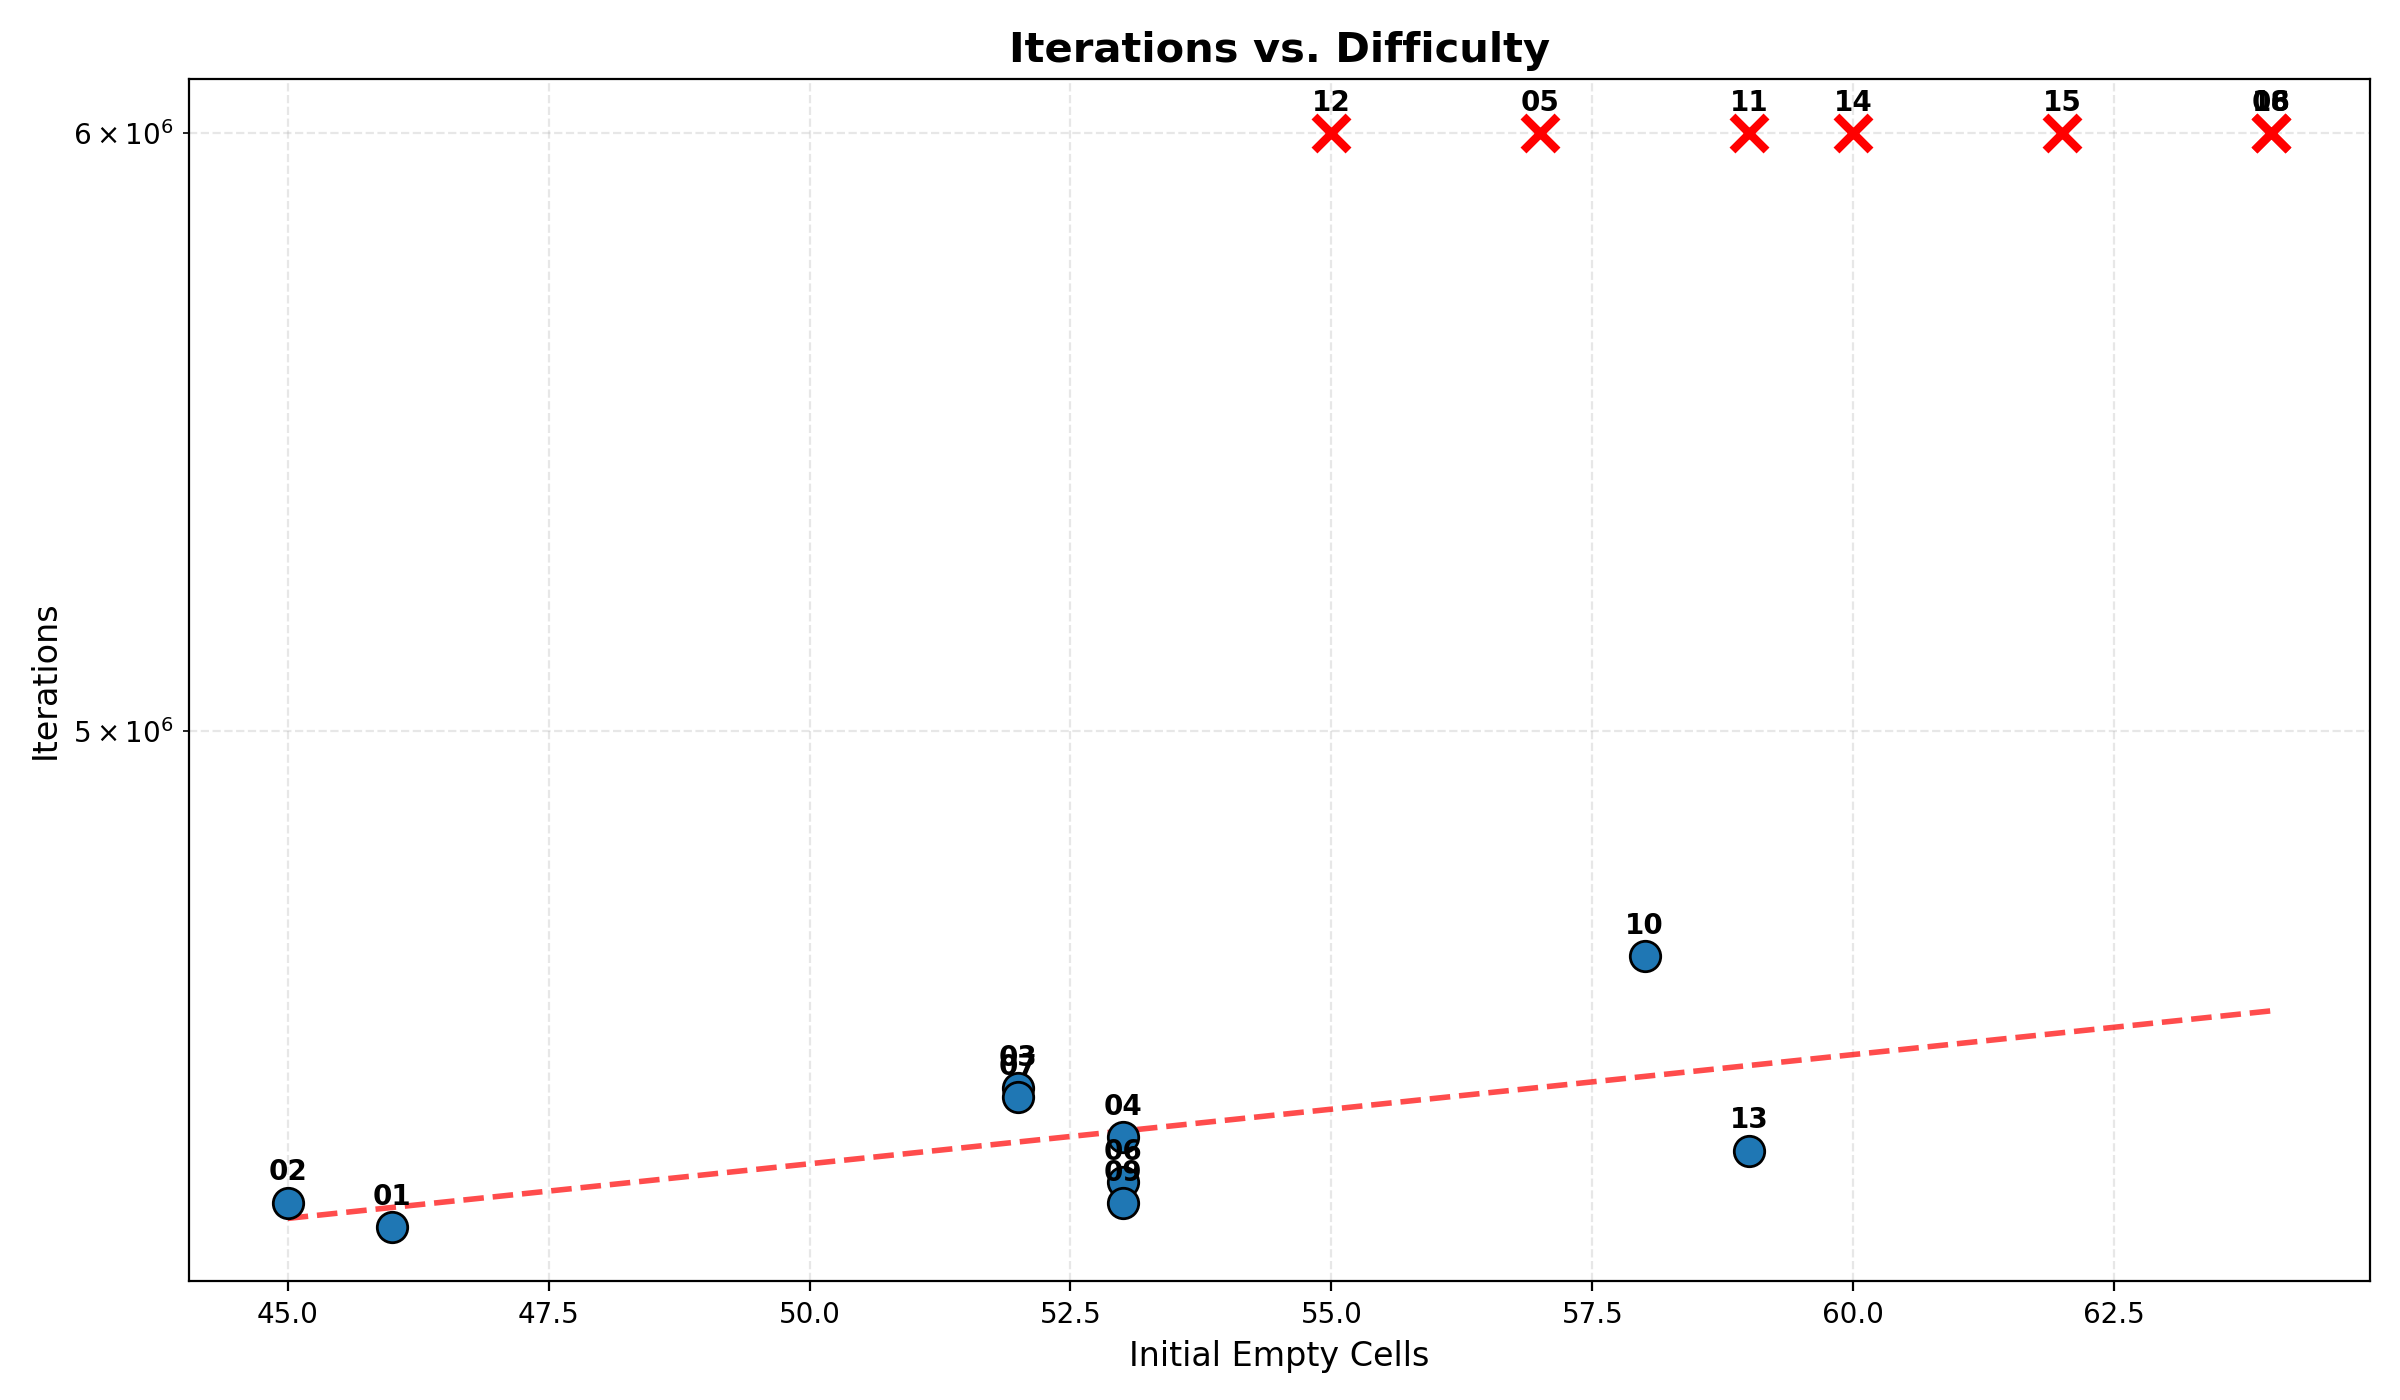

In [14]:
display(Image("ok/performance.png"))

Na powyższym wykresie przez czerwony X oznaczmy plansze których nie udało się rozwiązać w związku z wpadnięciem w minimum lokalne, więc program działał do limitu iteracji, ale dopasowania dokonujemy tylko względem tych którym udało się znaleźć rozwiązanie.

Liczba pustych miejsc ma niewielkie znaczenie co do liczby iteracji, można zauważyć lekką tendencję wzrostową, ale nie jest to nic znacznego. Można też zauważyć, że większe znaczenie względem tego czy uda się rozwiązać daną planszę, ma jej poziom trudności niż liczba pustych pól.